# Industrial case-study replication — verified paper-aligned version

This notebook starts from the original case-study code used for the pre-revision manuscript, but the computational specification has been reconciled with the current paper while preserving the original figure-producing cells exactly.

**Environment.** Run with the local `MCSC312` Python environment and a working local Gurobi license. Required plotting packages include `matplotlib`, `seaborn`, and `scienceplots`. No Colab credentials or notebook-level package installation are required.

**Paper-aligned stochastic specification.** Growth products launch independently with probability 0.75; conditional on launch, Low/Base/High are equiprobable. Thus Low/Base/High/NoLaunch each have unconditional probability 0.25 for Growth products. Planning uses 50 SAA scenarios (seed 123); evaluation uses an independent 300-scenario sample (seed 456). Capacity is the deterministic practitioner forecast. The investment and valuation horizons are both 2025–2032.

Stored outputs have been cleared. Run the notebook from top to bottom to regenerate the designs, figures, and paper-ready result files.


In [42]:
import contextlib
import itertools
import math
import os
import random
from collections import Counter
from pathlib import Path

import gurobipy as gp
import gurobipy as grb
from gurobipy import GRB
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import networkx as nx
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.spatial import distance_matrix

try:
    import scienceplots  # registers the original 'science' Matplotlib style
except ImportError as exc:
    raise ImportError(
        "SciencePlots is required to reproduce the manuscript figures. "
        "Install it in MCSC312, e.g. `conda install -c conda-forge scienceplots`."
    ) from exc

# Preserve the plotting style used by the original case-study notebook.
plt.style.use('science')

print("Gurobi version:", gp.gurobi.version())
print("Python/Gurobi environment ready; local Gurobi licensing will be used automatically.")


Gurobi version: (13, 0, 1)
Python/Gurobi environment ready; local Gurobi licensing will be used automatically.


In [43]:
# -----------------------------------------------------------------------------
# 1. Planning & valuation horizons (calendar-based)
# -----------------------------------------------------------------------------

# The industrial case study uses the full company forecast window for both
# strategic investment timing and NPV valuation.
planning_start = 2025
planning_end   = 2032
valuation_end  = 2032

T_I = list(range(planning_start, planning_end + 1))   # Investment: 2025–2032
T_V = list(range(planning_start, valuation_end + 1)) # Valuation: 2025–2032

theta = len(T_I) - 1
nu    = len(T_V) - 1

if not set(T_I).issubset(T_V):
    raise ValueError("Investment years must be contained in the valuation horizon.")
if max(T_I) > max(T_V):
    raise ValueError("The investment horizon cannot extend beyond the valuation horizon.")

print("Investment horizon (T_I):", T_I)
print("Valuation horizon  (T_V):", T_V)
print("theta =", theta, " nu =", nu)


Investment horizon (T_I): [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032]
Valuation horizon  (T_V): [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032]
theta = 7  nu = 7


In [44]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# Case-study stochastic specification
# ============================================================
PLANNING_N_SAMPLES = 50
PLANNING_SEED = 123
EVALUATION_N_SAMPLES = 500
EVALUATION_SEED = 456
LAUNCH_SUCCESS_PROB = 0.8

DATA_DIR = Path("")

IJ_PATH   = DATA_DIR / "IJ.csv"
CIST_PATH = DATA_DIR / "c_ist.csv"
DJST_PATH = DATA_DIR / "d_jst.csv"
RJ_PATH   = DATA_DIR / "r_j.csv"

# ============================================================
# Load and normalize source data
# ============================================================
IJ   = pd.read_csv(IJ_PATH)
cist = pd.read_csv(CIST_PATH)
djst = pd.read_csv(DJST_PATH)
rj   = pd.read_csv(RJ_PATH)

if "Machine" in IJ.columns:
    IJ = IJ.rename(columns={"Machine": "i"})
if "Product" in IJ.columns:
    IJ = IJ.rename(columns={"Product": "j"})
if not {"i", "j", "Segment"}.issubset(IJ.columns):
    raise ValueError("IJ.csv must contain Machine/Product/Segment information.")

if "Product" in rj.columns:
    rj = rj.rename(columns={"Product": "j"})
profit_col = next(
    (c for c in ["p_j", "Revenue", "profit", "price", "revenue", "p"] if c in rj.columns),
    None,
)
if profit_col is None:
    raise ValueError("r_j.csv must contain a per-product operating-profit column.")
rj = rj.rename(columns={profit_col: "p_j"})

djst = djst.rename(columns={"Product": "j", "Year": "t"})
if not {"j", "t", "Low", "Base", "High"}.issubset(djst.columns):
    raise ValueError("d_jst.csv must contain Product, Year, Low, Base, and High.")
d_long = djst.melt(
    id_vars=["j", "t"],
    value_vars=["Low", "Base", "High"],
    var_name="s_label",
    value_name="demand",
)

cist = cist.rename(columns={"Machine": "i", "Year": "t"})
cap_col = next(
    (c for c in ["Capacity", "capacity", "CapacityHours", "cap", "c"] if c in cist.columns),
    None,
)
if cap_col is None:
    raise ValueError("c_ist.csv must contain a capacity column.")
cist = cist.rename(columns={cap_col: "capacity"})

# ============================================================
# Sets and source-data checks
# ============================================================
I = sorted(IJ["i"].unique().tolist())
J = sorted(IJ["j"].unique().tolist())
T = sorted(d_long["t"].unique().tolist())

if T != list(T_V):
    raise ValueError(f"Demand-data years {T} do not match valuation horizon {T_V}.")

segment_rows = IJ[["j", "Segment"]].drop_duplicates()
segment_counts = segment_rows.groupby("j")["Segment"].nunique()
if (segment_counts != 1).any():
    raise ValueError("Each product must have exactly one lifecycle Segment in IJ.csv.")
product_segment = segment_rows.set_index("j")["Segment"].to_dict()

expected_segments = {"Mature", "Growth", "Decline"}
unknown_segments = set(product_segment.values()) - expected_segments
if unknown_segments:
    raise ValueError(f"Unexpected product segments: {sorted(unknown_segments)}")

growth_products = [j for j in J if product_segment[j] == "Growth"]
mature_products = [j for j in J if product_segment[j] == "Mature"]
decline_products = [j for j in J if product_segment[j] == "Decline"]

p_j = rj[["j", "p_j"]].drop_duplicates().set_index("j")["p_j"].to_dict()
d_lookup = d_long.set_index(["j", "s_label", "t"])["demand"].to_dict()

cap_it = cist[["i", "t", "capacity"]].drop_duplicates()
missing_capacity = [
    (i, t) for i in I for t in T_V
    if not ((cap_it["i"] == i) & (cap_it["t"] == t)).any()
]
if missing_capacity:
    raise ValueError(f"Missing capacity observations, e.g. {missing_capacity[:5]}.")

# ============================================================
# Scenario generator
# ============================================================
BASE_STATES = ("Low", "Base", "High")
GROWTH_STATES = ("Low", "Base", "High", "NoLaunch")

def build_case_study_scenarios(n_samples, seed):
    """
    Draw an SAA sample from the case-study demand distribution.

    Mature/Decline:
        Low/Base/High with probability 1/3 each.

    Growth:
        launch succeeds independently with probability 0.75;
        conditional on success, Low/Base/High are equally likely.
        Therefore each successful trajectory has unconditional probability
        0.75/3 = 0.25 and NoLaunch has probability 0.25.

    Capacity follows the company forecast deterministically and is replicated
    across sampled demand scenarios.
    """
    rng = np.random.default_rng(seed)
    sampled_scenarios = []

    p_success_state = LAUNCH_SUCCESS_PROB / 3.0
    growth_probs = [
        p_success_state,
        p_success_state,
        p_success_state,
        1.0 - LAUNCH_SUCCESS_PROB,
    ]

    for _ in range(n_samples):
        assignment = {}
        for j in J:
            if product_segment[j] == "Growth":
                assignment[j] = rng.choice(GROWTH_STATES, p=growth_probs)
            else:
                assignment[j] = rng.choice(BASE_STATES, p=[1/3, 1/3, 1/3])
        sampled_scenarios.append(assignment)

    scenario_ids = list(range(n_samples))
    probabilities = {s: 1.0 / n_samples for s in scenario_ids}

    demand = {}
    for s, assignment in zip(scenario_ids, sampled_scenarios):
        for j in J:
            state = assignment[j]
            for t in T_V:
                if state == "NoLaunch":
                    demand[j, s, t] = 0.0
                else:
                    demand[j, s, t] = float(d_lookup[j, state, t])

    capacity = {}
    cap_lookup = cap_it.set_index(["i", "t"])["capacity"].to_dict()
    for i in I:
        for s in scenario_ids:
            for t in T_V:
                capacity[i, s, t] = float(cap_lookup[i, t])

    demand_df = pd.DataFrame(
        [(j, s, t, demand[j, s, t]) for s in scenario_ids for j in J for t in T_V],
        columns=["j", "s", "t", "demand"],
    )
    capacity_df = pd.DataFrame(
        [(i, s, t, capacity[i, s, t]) for s in scenario_ids for i in I for t in T_V],
        columns=["i", "s", "t", "capacity"],
    )
    assignment_df = (
        pd.DataFrame(sampled_scenarios, index=scenario_ids)
        .reset_index()
        .rename(columns={"index": "s"})
    )

    return (
        scenario_ids,
        probabilities,
        sampled_scenarios,
        assignment_df,
        demand,
        demand_df,
        capacity,
        capacity_df,
    )

def save_case_study_scenarios(output_dir, assignment_df, demand_df, capacity_df):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    assignment_df.to_csv(output_dir / "scenario_assignments.csv", index=False)
    demand_df.to_csv(output_dir / "d_j_s_t_sampled.csv", index=False)
    capacity_df.to_csv(output_dir / "c_ist.csv", index=False)
    pd.DataFrame(list(p_j.items()), columns=["j", "p_j"]).to_csv(
        output_dir / "p_j.csv", index=False
    )

# ============================================================
# Planning SAA sample
# ============================================================
(
    S,
    π_s,
    sampled_scenarios,
    scenario_assign_df,
    d_j_s_t,
    d_j_s_t_df,
    c_ist,
    cap_df,
) = build_case_study_scenarios(PLANNING_N_SAMPLES, PLANNING_SEED)

PLANNING_OUTPUT_DIR = DATA_DIR / "saa_outputs" / "planning"
save_case_study_scenarios(
    PLANNING_OUTPUT_DIR, scenario_assign_df, d_j_s_t_df, cap_df
)

# p_ij = product operating profit, independent of machine.
p_ij = {(i, j): float(p_j[j]) for i in I for j in J}
pd.DataFrame(
    [(i, j, v) for (i, j), v in p_ij.items()],
    columns=["i", "j", "p_ij"],
).to_csv(PLANNING_OUTPUT_DIR / "p_ij.csv", index=False)

growth_draws = [
    sampled_scenarios[s][j]
    for s in S
    for j in growth_products
]
empirical_launch_rate = (
    np.mean([state != "NoLaunch" for state in growth_draws])
    if growth_draws else np.nan
)

print(f"|I|={len(I)}, |J|={len(J)}, |T|={len(T)}, |S|={len(S)}")
print(
    f"Products: Mature={len(mature_products)}, "
    f"Growth={len(growth_products)}, Decline={len(decline_products)}"
)
print(f"Sum pi_s: {sum(π_s.values()):.6f}")
print(f"Configured Growth launch success probability: {LAUNCH_SUCCESS_PROB:.3f}")
print(f"Empirical Growth launch rate in planning SAA: {empirical_launch_rate:.3f}")


|I|=5, |J|=18, |T|=8, |S|=50
Products: Mature=4, Growth=9, Decline=5
Sum pi_s: 1.000000
Configured Growth launch success probability: 0.800
Empirical Growth launch rate in planning SAA: 0.802


### Original paper figure code

The following visualization cells are intentionally preserved from the pre-revision case-study notebook. Their plotting logic, sizing, colors, labels, and PDF filenames are unchanged so regenerated figures can be compared directly with the files used in Overleaf. Only the upstream model/scenario data have been corrected.


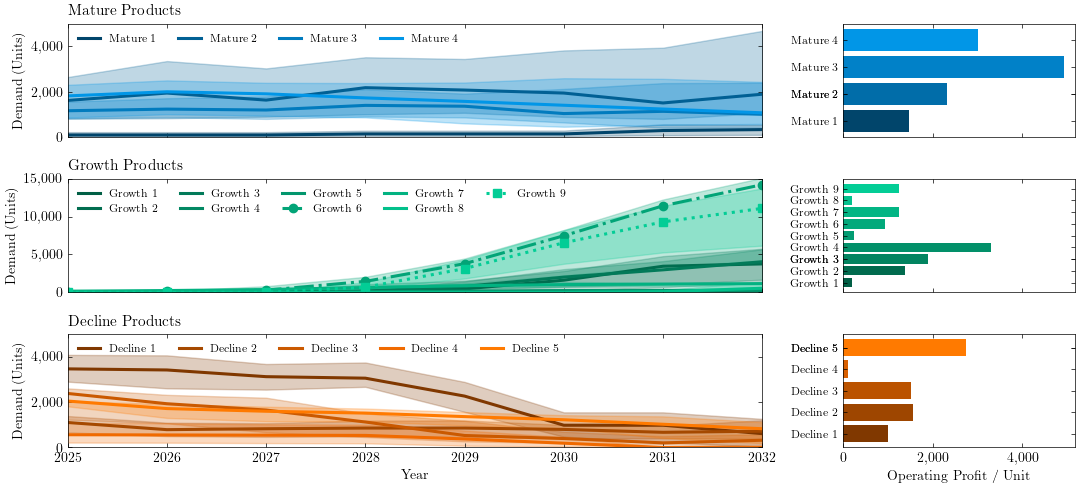

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.ticker import StrMethodFormatter

# ============================================================
# Load data
# ============================================================
IJ = pd.read_csv("IJ.csv")
djst = pd.read_csv("d_jst.csv")
rj = pd.read_csv("r_j.csv")

# Normalize column names
IJ = IJ.rename(columns={"Machine": "i", "Product": "j"})
djst = djst.rename(columns={"Product": "j"})
rj = rj.rename(columns={"Product": "j", "OperatingProfitPerUnit": "Profit"})

# Ensure numeric columns
for col in ["Year", "Low", "Base", "High"]:
    djst[col] = pd.to_numeric(djst[col], errors="coerce")
djst = djst.dropna(subset=["Year", "Low", "Base", "High"])

# ============================================================
# Map internal segment → lifecycle name
# ============================================================
segment_to_lifecycle = {
    "Decline": "Decline",
    "Growth": "Growth",
    "Mature": "Mature",
}
IJ["Lifecycle"] = IJ["Segment"].map(segment_to_lifecycle)
rj = rj.merge(IJ[["j", "Lifecycle"]], on="j", how="left")

# ============================================================
# Palette and helper
# ============================================================
base_palette = sns.color_palette("colorblind", 6)
lifecycle_order = ["Mature", "Growth", "Decline"]
base_hues = {
    "Mature": base_palette[0],
    "Growth": base_palette[2],
    "Decline": base_palette[3],
}

def generate_shades(base_color, n):
    base = np.array(mcolors.to_rgb(base_color), dtype=float)
    factors = np.linspace(0.6, 1.3, n)
    return [tuple(np.clip(base * f, 0, 1)) for f in factors]

# ============================================================
# Build figure: 2 columns (Demand + Profit)
# ============================================================
fig, axes = plt.subplots(len(lifecycle_order), 2,
                         figsize=(11, 1.75 * len(lifecycle_order)),
                         sharex="col",
                         gridspec_kw={'width_ratios': [3, 1]})

if len(lifecycle_order) == 1:
    axes = [axes]

for row, lifecycle in enumerate(lifecycle_order):
    # Left column: Demand plot
    ax_demand = axes[row, 0]
    seg_products = IJ[IJ["Lifecycle"] == lifecycle]["j"].unique()
    base_color = base_hues[lifecycle]
    n_products = len(seg_products)
    shades = generate_shades(base_color, max(n_products, 3))

    for product, color in zip(seg_products, shades):
        subset = djst[djst["j"] == product].sort_values("Year")
        if subset.empty:
            continue

        line_style, marker_style = "-", None
        if lifecycle == "Growth":
            if "6" in str(product):
                line_style = "-."
                marker_style = "o"
            elif "9" in str(product):
                line_style = ":"
                marker_style = "s"

        ax_demand.plot(subset["Year"], subset["Base"],
                       label=product, color=color, linewidth=2.2,
                       linestyle=line_style, marker=marker_style)
        ax_demand.fill_between(subset["Year"], subset["Low"], subset["High"],
                               color=color, alpha=0.25)

    ax_demand.set_title(f"{lifecycle} Products", fontsize=11, loc="left")
    ax_demand.set_ylabel("Demand (Units)", fontsize=10)
    ax_demand.set_xlim(2025, 2032)
    ax_demand.legend(fontsize=8, loc="upper left", ncol=5, frameon=False)

    # Format ticks with commas and disable minor ticks
    ax_demand.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax_demand.minorticks_off()
    ax_demand.grid(False)

    # Set y-limits
    if lifecycle == "Mature":
        ax_demand.set_ylim(0, 5000)
    elif lifecycle == "Growth":
        ax_demand.set_ylim(0, 15000)
    elif lifecycle == "Decline":
        ax_demand.set_ylim(0, 5000)

    # Right column: Profit per unit
    ax_profit = axes[row, 1]
    seg_profit = rj[rj["Lifecycle"] == lifecycle].copy()

    # --- Ensure numeric and sort alphabetically ---
    profit_col = "Profit" if "Profit" in seg_profit.columns else "Revenue"
    seg_profit = seg_profit.sort_values("j", ascending=True)
    seg_profit["color"] = generate_shades(base_color, len(seg_profit))

    ax_profit.barh(seg_profit["j"], seg_profit[profit_col],
                   color=seg_profit["color"])

    ax_profit.set_yticks(seg_profit["j"])
    ax_profit.set_yticklabels(seg_profit["j"], fontsize=8)

    ax_profit.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax_profit.minorticks_off()
    ax_profit.grid(False)

# Common x-labels
axes[-1, 0].set_xlabel("Year", fontsize=10)
axes[-1, 1].set_xlabel("Operating Profit / Unit", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("demand_profit.pdf", bbox_inches="tight")
plt.show()


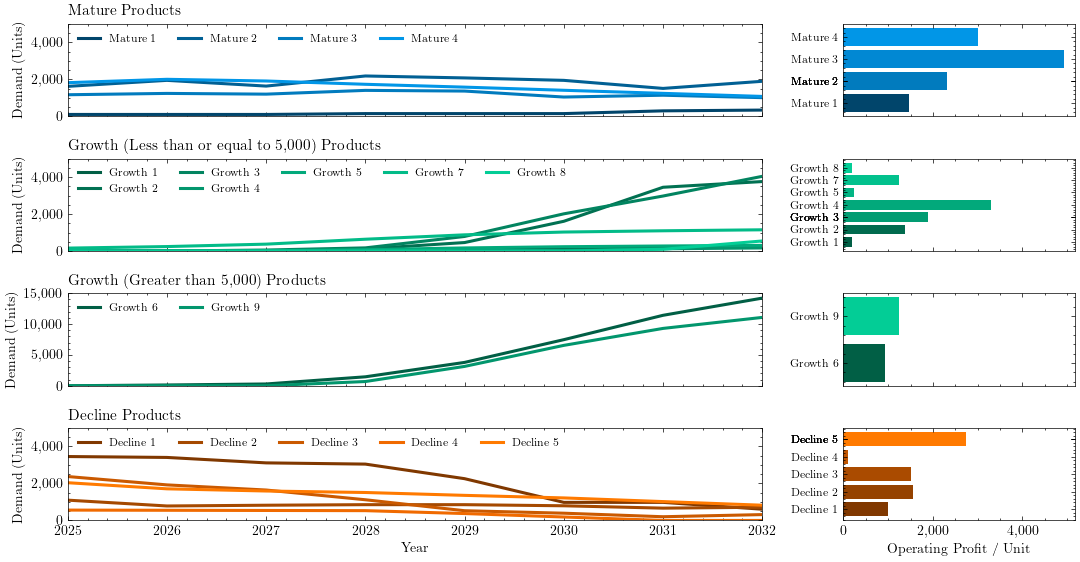

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.ticker import StrMethodFormatter

# ============================================================
# Load data
# ============================================================
IJ = pd.read_csv("IJ.csv")
djst = pd.read_csv("d_jst.csv")
rj = pd.read_csv("r_j.csv")

# Normalize column names
IJ = IJ.rename(columns={"Machine": "i", "Product": "j"})
djst = djst.rename(columns={"Product": "j"})
rj = rj.rename(columns={"Product": "j"})

# Ensure numeric columns
for col in ["Year", "Low", "Base", "High"]:
    djst[col] = pd.to_numeric(djst[col], errors="coerce")
djst = djst.dropna(subset=["Year", "Low", "Base", "High"])

# Map Segment to Lifecycle
IJ["Lifecycle"] = IJ["Segment"].map({
    "Decline": "Decline",
    "Growth": "Growth",
    "Mature": "Mature",
})

rj = rj.merge(IJ[["j", "Lifecycle"]], on="j", how="left")

# ============================================================
# Split Growth using peak Base demand
# ============================================================
djst_peak = djst.groupby("j")["Base"].max().reset_index()
lifecycle_map = IJ.drop_duplicates(subset="j").set_index("j")["Lifecycle"]
djst_peak["Lifecycle"] = djst_peak["j"].map(lifecycle_map)

# Split growth into ≤5000 and >5000
growth_low = djst_peak[(djst_peak["Lifecycle"] == "Growth") & (djst_peak["Base"] <= 5000)]["j"]
growth_high = djst_peak[(djst_peak["Lifecycle"] == "Growth") & (djst_peak["Base"] > 5000)]["j"]

# Reassign lifecycles
IJ["LifecycleGrouped"] = IJ["j"].apply(
    lambda x: "Growth (Less than or equal to 5,000)" if x in growth_low.values
    else "Growth (Greater than 5,000)" if x in growth_high.values
    else IJ.loc[IJ["j"] == x, "Lifecycle"].values[0]
)

# Update rj with grouped lifecycle labels
rj = rj.merge(IJ[['j', 'LifecycleGrouped']], on='j', how='left')

# ============================================================
# Setup colors and helper
# ============================================================
base_palette = sns.color_palette("colorblind", 6)
lifecycles = ["Mature", "Growth (Less than or equal to 5,000)", "Growth (Greater than 5,000)", "Decline"]
base_hues = {
    "Mature": base_palette[0],
    "Growth (Less than or equal to 5,000)": base_palette[2],
    "Growth (Greater than 5,000)": base_palette[2],
    "Decline": base_palette[3],
}

def generate_shades(base_color, n):
    base = np.array(mcolors.to_rgb(base_color), dtype=float)
    factors = np.linspace(0.6, 1.3, n)
    return [tuple(np.clip(base * f, 0, 1)) for f in factors]

# ============================================================
# Build figure: 4 rows, 2 columns
# ============================================================
fig, axes = plt.subplots(len(lifecycles), 2, figsize=(11, 6),
                         sharex="col", gridspec_kw={'width_ratios': [3, 1]})

for row, lifecycle in enumerate(lifecycles):
    ax_demand, ax_profit = axes[row]

    # Select products for this lifecycle
    seg_products = IJ[IJ["LifecycleGrouped"] == lifecycle]["j"].unique()
    seg_profit = rj[rj["LifecycleGrouped"] == lifecycle].copy()

    # Plot demand curve
    base_color = base_hues[lifecycle]
    shades = generate_shades(base_color, max(len(seg_products), 3))

    for product, color in zip(seg_products, shades):
        subset = djst[djst["j"] == product].sort_values("Year")
        if subset.empty:
            continue
        ax_demand.plot(subset["Year"], subset["Base"], label=product,
                       color=color, linewidth=2.2)
        # ax_demand.fill_between(subset["Year"], subset["Low"], subset["High"],
        #                        color=color, alpha=0.3)

    ax_demand.set_title(f"{lifecycle} Products", fontsize=11, loc="left")
    ax_demand.set_ylabel("Demand (Units)", fontsize=10)
    ax_demand.legend(fontsize=8, loc="upper left", ncol=5, frameon=False)
    ax_demand.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax_demand.grid(False)

    # Set y-limits
    if lifecycle in ["Mature", "Growth (Less than or equal to 5,000)", "Decline"]:
        ax_demand.set_ylim(0, 5000)
    elif lifecycle == "Growth (Greater than 5,000)":
        ax_demand.set_ylim(0, 15000)
    ax_demand.set_xlim(2025, 2032)

    # Plot profit as horizontal bar chart
    seg_profit = seg_profit[seg_profit["j"].isin(seg_products)].sort_values("j")

    # Determine profit column
    if 'Profit' in seg_profit.columns:
        profit_col = 'Profit'
    elif 'OperatingProfitPerUnit' in seg_profit.columns:
        profit_col = 'OperatingProfitPerUnit'
    elif 'Revenue' in seg_profit.columns:
        profit_col = 'Revenue'
    else:
        raise KeyError("Profit column not found in r_j.csv. Available columns: " + ", ".join(seg_profit.columns))

    seg_profit["color"] = generate_shades(base_color, len(seg_profit))
    ax_profit.barh(seg_profit["j"], seg_profit[profit_col], color=seg_profit["color"])
    ax_profit.set_yticks(seg_profit["j"])
    ax_profit.set_yticklabels(seg_profit["j"], fontsize=8)
    ax_profit.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
    ax_profit.grid(False)

axes[-1, 0].set_xlabel("Year", fontsize=10)
axes[-1, 1].set_xlabel("Operating Profit / Unit", fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("demand_profit_4rows.pdf", bbox_inches="tight")
plt.show()


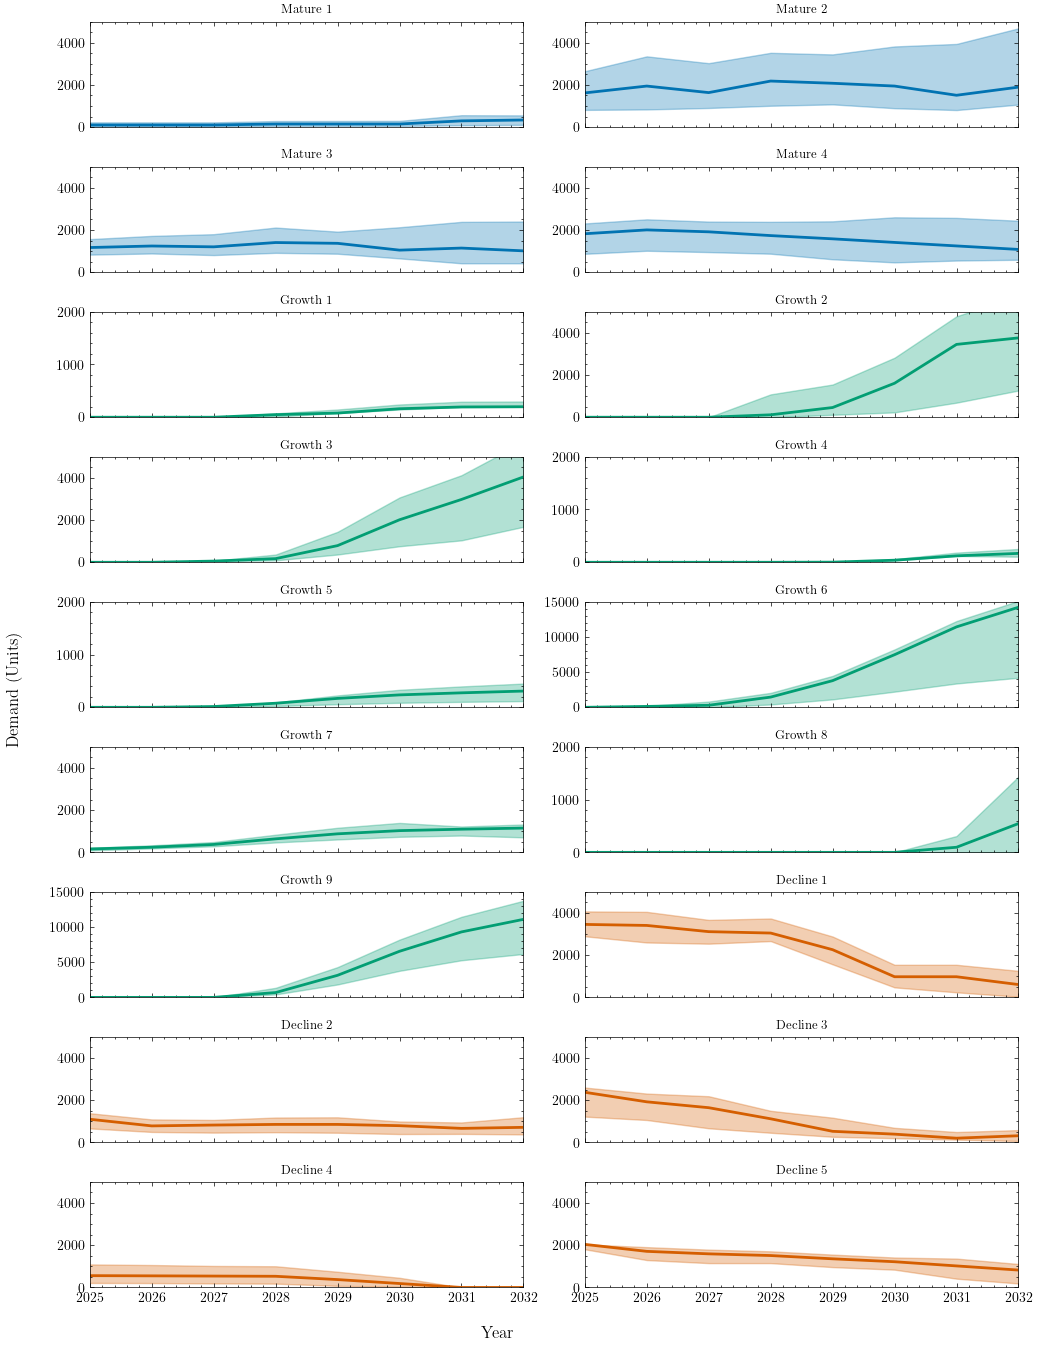

Saved sorted demand chart with shared axes to demand_2x9_sorted_grid_with_labels.pdf


In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.ticker import StrMethodFormatter

# Setup color palette
base_palette = sns.color_palette("colorblind", 6)
base_hues = {
    "Mature": base_palette[0],
    "Growth (Less than or equal to 5,000)": base_palette[2],
    "Growth (Greater than 5,000)": base_palette[2],
    "Decline": base_palette[3],
}

# Helper for shading colors
def generate_shades(base_color, n):
    base = np.array(mcolors.to_rgb(base_color), dtype=float)
    factors = np.linspace(0.6, 1.3, n)
    return [tuple(np.clip(base * f, 0, 1)) for f in factors]

# Function to extract numeric rank from product name
def extract_rank(product_name):
    try:
        return int(product_name.split()[-1])
    except ValueError:
        return 1e9

# Sort products: Mature 1-4, Growth 1-9, Decline 1-5
products = IJ.copy()
products["Rank"] = products["j"].apply(extract_rank)
products["Order"] = products["LifecycleGrouped"].map({
    "Mature": 1,
    "Growth (Less than or equal to 5,000)": 2,
    "Growth (Greater than 5,000)": 2,
    "Decline": 3,
})
products = products.sort_values(by=["Order", "Rank"])
sorted_products = products["j"].unique()

# Plot grid: 2 columns × 9 rows
ncols = 2
nrows = 9
fig, axes = plt.subplots(nrows, ncols, figsize=(11, 14), sharex=True, sharey=False)
axes = axes.flatten()

for idx, product in enumerate(sorted_products):
    if idx >= nrows * ncols:
        break

    ax = axes[idx]
    lifecycle = IJ.loc[IJ["j"] == product, "LifecycleGrouped"].values[0]
    base_color = base_hues[lifecycle]

    # Plot demand
    subset = djst[djst["j"] == product].sort_values("Year")
    if not subset.empty:
        ax.plot(subset["Year"], subset["Base"], color=base_color, linewidth=2)
        ax.fill_between(subset["Year"], subset["Low"], subset["High"], color=base_color, alpha=0.3)

    # Title and labels
    ax.set_title(product, fontsize=9)

    # Dynamic Y-limits
    if "Growth" in lifecycle and ("6" in str(product) or "9" in str(product)):
        ax.set_ylim(0, 15000)
    elif "Growth" in lifecycle and ("1" in str(product) or "5" in str(product) or "8" in str(product) or "4" in str(product)):
        ax.set_ylim(0, 2000)
    else:
        ax.set_ylim(0, 5000)
    ax.set_xlim(2025, 2032)
    ax.grid(False)

# Remove empty subplots if fewer than 18
for ax in axes[len(sorted_products):]:
    ax.set_visible(False)

# Shared axis labels
fig.text(0.5, 0.04, "Year", ha="center", va="center", fontsize=12)
fig.text(0.06, 0.5, "Demand (Units)", ha="center", va="center", rotation="vertical", fontsize=12)

# Adjust layout and export
plt.tight_layout(rect=[0.08, 0.05, 1, 1])
plt.savefig("demand_2x9_sorted_grid_with_labels.pdf", bbox_inches="tight")
plt.show()

print("Saved sorted demand chart with shared axes to demand_2x9_sorted_grid_with_labels.pdf")


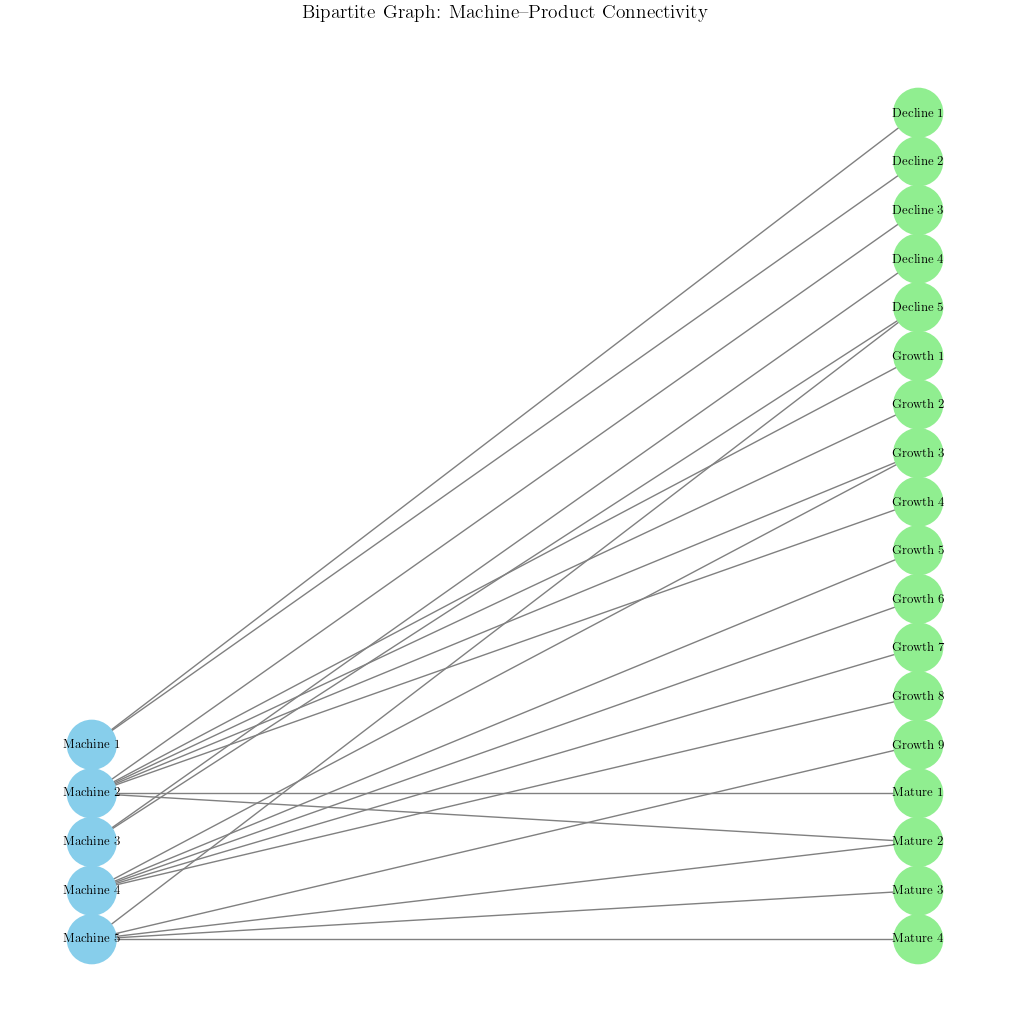

In [48]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# ============================================================
# 1) Load IJ.csv and normalize columns
# ============================================================
IJ = pd.read_csv("IJ.csv")

# Expect columns like Machine, Product, Segment
if "Machine" in IJ.columns:
    IJ = IJ.rename(columns={"Machine": "i"})
if "Product" in IJ.columns:
    IJ = IJ.rename(columns={"Product": "j"})

# Optional: keep segment info if available
has_segment = "Segment" in IJ.columns

# ============================================================
# 2) Build bipartite graph
# ============================================================
B = nx.Graph()

# Add nodes with bipartite labels
machines = IJ["i"].unique().tolist()
products = IJ["j"].unique().tolist()

B.add_nodes_from(machines, bipartite=0, type="machine")
B.add_nodes_from(products, bipartite=1, type="product")

# Add edges (Machine ↔ Product)
edges = [tuple(x) for x in IJ[["i", "j"]].drop_duplicates().values]
B.add_edges_from(edges)

# ============================================================
# 3) Create layout (machines on left, products on right)
# ============================================================
pos = {}

# Assign y positions evenly spaced for readability
machines_sorted = sorted(machines)
products_sorted = sorted(products)

for idx, m in enumerate(machines_sorted):
    pos[m] = (0, len(machines_sorted) - idx)

for idx, p in enumerate(products_sorted):
    pos[p] = (1, len(products_sorted) - idx)

# ============================================================
# 4) Draw the graph (with better spacing)
# ============================================================
plt.figure(figsize=(10, 10))
nx.draw(
    B, pos,
    with_labels=True,
    node_color=["skyblue" if n in machines else "lightgreen" for n in B.nodes()],
    node_size=1200,
    edge_color="gray",
    linewidths=1.5,
    font_size=9,
)

plt.title("Bipartite Graph: Machine–Product Connectivity", fontsize=14)
plt.axis("off")

# Add small padding instead of tight_layout
plt.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)

plt.show()



In [49]:
M = I
P = J

r = 0.075
f_i = {i: 2_000_000 for i in M}              # annual fixed OPEX
g_i = {i: 0.0 for i in M}                    # all five case-study machines already exist
h_ij = {(i, j): 1_000_000 for i in M for j in P}  # new capability qualification CAPEX
L_i = {i: 10 for i in M}
throughput = 1.0

# Baseline capabilities from the observed network.
IJ = IJ[IJ["i"].isin(M) & IJ["j"].isin(P)].copy()
pre_installed_arcs = list(
    map(tuple, IJ[["i", "j"]].dropna().drop_duplicates().to_numpy())
)
pre_installed_machines = sorted({i for i, _ in pre_installed_arcs})

print(f"Baseline capabilities: {len(pre_installed_arcs)}")
print(f"Existing machines: {len(pre_installed_machines)}")

# Existing qualifications and machines require no incremental capital investment.
for i, j in pre_installed_arcs:
    h_ij[i, j] = 0.0
for i in pre_installed_machines:
    g_i[i] = 0.0


Baseline capabilities: 21
Existing machines: 5


In [50]:
# -----------------------------------------------------------------------------
# Multi-period two-stage stochastic program
# -----------------------------------------------------------------------------

base_year = min(T_I)
t_theta = max(T_I)
T_V_max = max(T_V)

m = gp.Model("Flexibility-Investment Multi-Period Two-Stage")

# Strategic decisions are non-anticipative across all SAA scenarios.
m_it   = m.addVars(M, T_I, vtype=GRB.BINARY, name="m")
a_ijt  = m.addVars(M, P, T_I, vtype=GRB.BINARY, name="a")
u_it   = m.addVars(M, T_I, vtype=GRB.BINARY, name="u")

# Operational recourse is scenario-specific.
x_ijst = m.addVars(M, P, S, T_V, vtype=GRB.CONTINUOUS, lb=0.0, name="x")
y_ijs  = m.addVars(M, P, S, lb=0.0, ub=1.0, name="y")

disc = lambda t: 1.0 / (1.0 + r) ** ((t - base_year) + 1)

profit_term = gp.quicksum(
    disc(t) * π_s[s] * p_ij[i, j] * x_ijst[i, j, s, t]
    for i, j, s, t in itertools.product(M, P, S, T_V)
)

opex_coeff = {}
for i in M:
    for tau in T_I:
        life_end = min(tau + L_i[i] - 1, T_V_max)
        opex_coeff[i, tau] = (
            f_i[i] * sum(disc(t) for t in range(tau, life_end + 1))
            if tau <= life_end else 0.0
        )
opex = gp.quicksum(
    opex_coeff[i, tau] * u_it[i, tau]
    for i in M for tau in T_I
)

capex_M = gp.quicksum(
    g_i[i] / (1.0 + r) ** (t - base_year) * u_it[i, t]
    for i, t in itertools.product(M, T_I)
)

capex_A = gp.LinExpr()
for i, j in itertools.product(M, P):
    for t in T_I:
        prev = 0 if t == base_year else a_ijt[i, j, t - 1]
        capex_A += (
            h_ij[i, j] / (1.0 + r) ** (t - base_year)
            * (a_ijt[i, j, t] - prev)
        )

m.setObjective(profit_term - opex - capex_M - capex_A, GRB.MAXIMIZE)

# Machine activation: once activated, a machine remains active through T_I.
m.addConstrs(
    (m_it[i, base_year] == u_it[i, base_year] for i in M),
    name="startup0",
)
m.addConstrs(
    (
        m_it[i, t] - m_it[i, t - 1] == u_it[i, t]
        for i in M for t in T_I if t > base_year
    ),
    name="startup",
)

# Capability persistence and machine linkage.
m.addConstrs(
    (
        a_ijt[i, j, t] >= a_ijt[i, j, t - 1]
        for i in M for j in P for t in T_I if t > base_year
    ),
    name="mono_arc",
)
m.addConstrs(
    (a_ijt[i, j, t] <= m_it[i, t] for i in M for j in P for t in T_I),
    name="arc_machine",
)

# A pre-qualified capability is available whenever its existing machine is active.
m.addConstrs(
    (
        a_ijt[i, j, t] == m_it[i, t]
        for i, j in pre_installed_arcs
        for t in T_I
    ),
    name="preinstalled_capability",
)

# Demand.
m.addConstrs(
    (
        gp.quicksum(x_ijst[i, j, s, t] for i in M) <= d_j_s_t[j, s, t]
        for j, s, t in itertools.product(P, S, T_V)
    ),
    name="demand",
)

# Capacity during and after the investment horizon.
m.addConstrs(
    (
        gp.quicksum(x_ijst[i, j, s, t] for j in P) / throughput
        <= c_ist[i, s, t]
        * (m_it[i, t] if t <= t_theta else m_it[i, t_theta])
        for i, s, t in itertools.product(M, S, T_V)
    ),
    name="capacity",
)

# Explicit lifetime restriction for valuation years after the investment horizon.
for i in M:
    for s in S:
        for t in T_V:
            if t > t_theta:
                alive_starts = [
                    tau for tau in T_I
                    if (t - L_i[i] + 1) <= tau <= min(t, t_theta)
                ]
                m.addConstr(
                    gp.quicksum(x_ijst[i, j, s, t] for j in P)
                    <= c_ist[i, s, t]
                    * gp.quicksum(u_it[i, tau] for tau in alive_starts),
                    name=f"lifetime_{i}_{s}_{t}",
                )

# Production requires a qualified capability.
m.addConstrs(
    (
        x_ijst[i, j, s, t] / throughput
        <= c_ist[i, s, t]
        * (a_ijt[i, j, t] if t <= t_theta else a_ijt[i, j, t_theta])
        for i, j, s, t in itertools.product(M, P, S, T_V)
    ),
    name="arc_link",
)

# Allocation-stability constraints are active only if T_V extends beyond T_I.
m.addConstrs(
    (
        x_ijst[i, j, s, t_theta]
        <= y_ijs[i, j, s] * d_j_s_t[j, s, t_theta]
        for i, j, s in itertools.product(M, P, S)
    ),
    name="share_def",
)
m.addConstrs(
    (
        x_ijst[i, j, s, t]
        <= y_ijs[i, j, s] * d_j_s_t[j, s, t]
        for i, j, s, t in itertools.product(M, P, S, T_V)
        if t > t_theta
    ),
    name="share_frozen",
)
m.addConstrs(
    (
        gp.quicksum(y_ijs[i, j, s] for i in M) == 1.0
        for j, s in itertools.product(P, S)
    ),
    name="share_sum",
)

m.Params.OutputFlag = 1
m.Params.Threads = 8
m.optimize()

if m.Status != GRB.OPTIMAL:
    raise RuntimeError(
        f"Multi-period planning model did not solve to optimality; status={m.Status}"
    )


Set parameter OutputFlag to value 1
Set parameter Threads to value 8
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 24.6.0 24G720)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
Threads  8

Optimize a model with 52158 rows, 41300 columns and 161886 nonzeros (Max)
Model fingerprint: 0xebe887da
Model has 36592 linear objective coefficients
Variable types: 40500 continuous, 800 integer (800 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+04]
  Objective range  [1e+00, 1e+07]
  Bounds range     [1e+00, 1e+00]
  RHS range        [4e-02, 2e+04]

Found heuristic solution: objective -0.0000000
Presolve removed 19848 rows and 15899 columns
Presolve time: 0.40s
Presolved: 32310 rows, 25401 columns, 102245 nonzeros
Variable types: 24924 continuous, 477 integer (477 binary)
Deterministic concurrent LP optimizer: primal and dual simplex
Showing primal log only...


Root simplex log..

In [51]:
a_ijt_multi = {key: value.X for key, value in a_ijt.items()}
m_it_multi = {key: value.X for key, value in m_it.items()}
u_it_multi = {key: value.X for key, value in u_it.items()}
x_ijst_multi = {key: value.X for key, value in x_ijst.items()}

In [52]:
# =========================
# 1) Undiscounted Gross Profit per period
# =========================
undiscounted_profit_period = {t: 0.0 for t in T_V}
for (i, j, s, t), xval in x_ijst_multi.items():
    profit = π_s[s] * p_ij[(i, j)] * xval
    undiscounted_profit_period[t] += profit

# =========================
# 2) Undiscounted Fixed OPEX per period
# =========================
undiscounted_fixed_operating_period = {t: 0.0 for t in T_V}
for t in T_V:
    period_cost = 0.0
    for i in M:
        Li = L_i[i]
        # Active in year t if there exists a start tau whose lifetime covers t
        active = any(
            (tau in T_I) and (tau <= t <= tau + Li - 1) and (u_it_multi.get((i, tau), 0.0) > 0.5)
            for tau in T_I
        )
        if active:
            period_cost -= f_i[i]   # keep your sign convention (cost negative)
    undiscounted_fixed_operating_period[t] = period_cost

# =========================
# 3) Undiscounted Machine CAPEX per period
# =========================
undiscounted_machine_period = {t: 0.0 for t in T_V}
for (i, t), uval in u_it_multi.items():
    if t in T_I and uval > 0:
        undiscounted_machine_period[t] += -g_i[i] * uval

# =========================
# 4) Undiscounted Arc CAPEX per period
# =========================
undiscounted_arc_period = {t: 0.0 for t in T_V}
for i in M:
    for j in P:
        for t in T_I:
            prev = 0.0 if t == base_year else a_ijt_multi.get((i, j, t - 1), 0.0)
            delta = a_ijt_multi.get((i, j, t), 0.0) - prev
            if delta != 0:
                undiscounted_arc_period[t] += -h_ij[i, j] * delta

# =========================
# 5) (Optional) pretty print or convert to Series/DataFrame
# =========================
print("undiscounted_profit_period")
print({t: round(v, 4) for t, v in undiscounted_profit_period.items()})

print("undiscounted_fixed_operating_period")
print({t: round(v, 4) for t, v in undiscounted_fixed_operating_period.items()})

print("undiscounted_machine_period")
print({t: round(v, 4) for t, v in undiscounted_machine_period.items()})

print("undiscounted_arc_period")
print({t: round(v, 4) for t, v in undiscounted_arc_period.items()})

# Optional: into pandas for easy tabular view
import pandas as pd
summary_df = pd.DataFrame({
    "Year": T_V,
    "Profit": [undiscounted_profit_period[t] for t in T_V],
    "FixedOPEX": [undiscounted_fixed_operating_period[t] for t in T_V],
    "MachineCAPEX": [undiscounted_machine_period.get(t, 0.0) for t in T_V],
    "ArcCAPEX": [undiscounted_arc_period.get(t, 0.0) for t in T_V],
})
summary_df["Total"] = summary_df[["Profit","FixedOPEX","MachineCAPEX","ArcCAPEX"]].sum(axis=1)
print(summary_df)

undiscounted_profit_period
{2025: 28756881.991, 2026: 28920290.762, 2027: 27452722.2833, 2028: 30487762.1776, 2029: 31340473.066, 2030: 37093795.2352, 2031: 41930153.6536, 2032: 46715495.6604}
undiscounted_fixed_operating_period
{2025: -4000000.0, 2026: -4000000.0, 2027: -4000000.0, 2028: -4000000.0, 2029: -4000000.0, 2030: -6000000.0, 2031: -8000000.0, 2032: -10000000.0}
undiscounted_machine_period
{2025: 0.0, 2026: 0.0, 2027: 0.0, 2028: 0.0, 2029: 0.0, 2030: 0.0, 2031: 0.0, 2032: 0.0}
undiscounted_arc_period
{2025: -4000000.0, 2026: -1000000.0, 2027: 0.0, 2028: -1000000.0, 2029: 0.0, 2030: -2000000.0, 2031: 0.0, 2032: 0.0}
   Year        Profit   FixedOPEX  MachineCAPEX   ArcCAPEX         Total
0  2025  2.875688e+07  -4000000.0           0.0 -4000000.0  2.075688e+07
1  2026  2.892029e+07  -4000000.0           0.0 -1000000.0  2.392029e+07
2  2027  2.745272e+07  -4000000.0           0.0        0.0  2.345272e+07
3  2028  3.048776e+07  -4000000.0           0.0 -1000000.0  2.548776e+07
4 

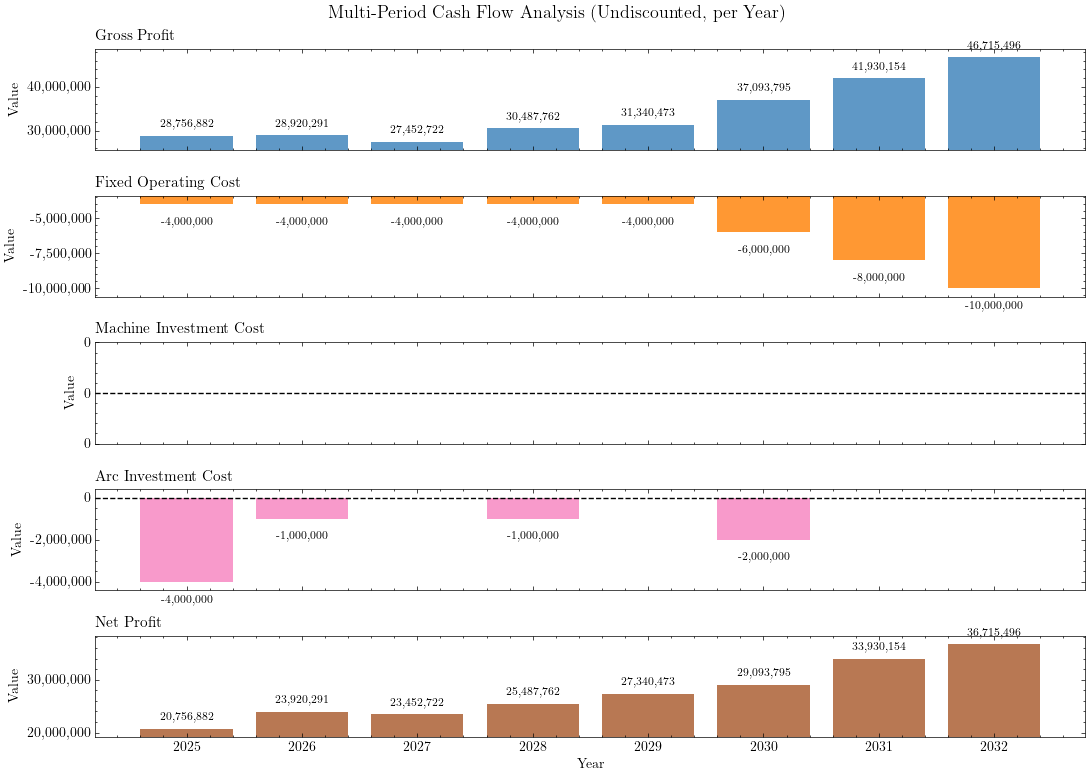

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ------------------------------
# 1) Period axis (calendar years)
# ------------------------------
years = list(T_V)  # e.g., [2025, ..., 2032]

# Build per-year net series (use .get to be safe)
total_net_profit_period = {
    t: (
        undiscounted_profit_period.get(t, 0.0)
        + undiscounted_fixed_operating_period.get(t, 0.0)
        + undiscounted_machine_period.get(t, 0.0)
        + undiscounted_arc_period.get(t, 0.0)
    )
    for t in years
}

series_dicts = {
    "Gross Profit":            undiscounted_profit_period,
    "Fixed Operating Cost":    undiscounted_fixed_operating_period,
    "Machine Investment Cost": undiscounted_machine_period,
    "Arc Investment Cost":     undiscounted_arc_period,
    "Net Profit":              total_net_profit_period,
}

# Colorblind-friendly palette
colors = ['#377eb8', '#ff7f00', '#4daf4a', '#f781bf', '#a65628']

# ------------------------------
# 2) Optional: export a tidy table for audit
# ------------------------------
summary_df = pd.DataFrame({
    "Year": years,
    "GrossProfit":            [series_dicts["Gross Profit"].get(t, 0.0)            for t in years],
    "FixedOpex":              [series_dicts["Fixed Operating Cost"].get(t, 0.0)    for t in years],
    "MachineCapex":           [series_dicts["Machine Investment Cost"].get(t, 0.0) for t in years],
    "ArcCapex":               [series_dicts["Arc Investment Cost"].get(t, 0.0)     for t in years],
    "NetProfit":              [series_dicts["Net Profit"].get(t, 0.0)              for t in years],
})
summary_df.to_csv("multi_period_cash_flow_analysis.csv", index=False)

# ------------------------------
# 3) Plot (bars per series, 5x1)
# ------------------------------
fig, axes = plt.subplots(5, 1, figsize=(11, 8), sharex=True)

# dynamic y-limits helper (with gentle padding)
def auto_ylim(vals, pad_ratio=0.10, min_span=1.0):
    vmin, vmax = min(vals), max(vals)
    span = max(vmax - vmin, min_span)
    pad = span * pad_ratio
    return (vmin - pad, vmax + pad)

for ax, ((title, data), color) in zip(axes, zip(series_dicts.items(), colors)):
    vals = [data.get(t, 0.0) for t in years]
    bars = ax.bar(years, vals, color=color, alpha=0.8)

    ax.axhline(0, color="black", linewidth=1, linestyle="--")
    ax.set_title(title, fontsize=11, loc="left")
    ax.set_ylabel("Value")

    # nicer grid & y-format
    #ax.grid(True, linestyle="--", alpha=0.35)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f"{int(round(x)):,}"))
    ax.set_ylim(*auto_ylim(vals))

    # annotate bars if sizeable
    for rect in bars:
        h = rect.get_height()
        if abs(h) >= 1:  # label only meaningful values
            offset = 4 if h >= 0 else -10
            va = 'bottom' if h >= 0 else 'top'
            ax.annotate(f'{int(round(h)):,}',
                        xy=(rect.get_x() + rect.get_width() / 2, h),
                        xytext=(0, offset),
                        textcoords="offset points",
                        ha='center', va=va, fontsize=8)

# x-axis
axes[-1].set_xlabel("Year")

# add a bit of space (avoid tight_layout warning)
plt.subplots_adjust(left=0.08, right=0.98, top=0.94, bottom=0.08, hspace=0.45)

plt.suptitle("Multi-Period Cash Flow Analysis (Undiscounted, per Year)", fontsize=13, y=0.995)
plt.savefig("multi_period_cash_flow_analysis.pdf")
plt.show()


In [54]:
# =============================================================================
# Multi-Period Arc & Machine Summary (calendar-year safe, using *_multi dicts)
# =============================================================================

base_year  = min(T_I)
final_year = max(T_I)

# -----------------------------------------------------------------------------
# 1) Extract active arcs and machine states by investment year
# -----------------------------------------------------------------------------
A_new = {
    t: [(i, j) for (i, j, tt), val in a_ijt_multi.items() if tt == t and val > 0.005]
    for t in T_I
}
m_new = {(i, t): val for (i, t), val in m_it_multi.items() if t in T_I}

final_arcs_multi = A_new[final_year]
n_arcs_mpts      = len(final_arcs_multi)
n_machines_mpts  = int(sum(m_new.get((i, final_year), 0.0) > 0.5 for i in M))

# -----------------------------------------------------------------------------
# 2) Identify baseline vs new arcs (full accounting)
# -----------------------------------------------------------------------------
baseline_edges = set(pre_installed_arcs)
final_edges    = set(final_arcs_multi)

new_edges_multi    = final_edges - baseline_edges
shared_edges_multi = final_edges & baseline_edges
all_display_edges  = baseline_edges | final_edges  # all preinstalled + new arcs

# -----------------------------------------------------------------------------
# 3) Year-on-Year Arc Additions (only *new* arcs, not previously installed)
# -----------------------------------------------------------------------------
print("\n=== Year-on-Year Arc Additions (New Only) ===")
times = sorted(T_I)

# Start with baseline arcs as the initially installed ones
installed_edges = set(baseline_edges)

for t in times:
    current_edges = set(A_new.get(t, []))
    # Only count arcs that appear for the first time (not in installed_edges)
    added_this_year = current_edges - installed_edges

    if added_this_year:
        print(f"Year {t}: Added {len(added_this_year)} new arcs → {sorted(added_this_year)}")
    else:
        print(f"Year {t}: No new arcs added.")

    # Update the cumulative set of installed arcs
    installed_edges |= added_this_year

# -----------------------------------------------------------------------------
# 4) Print final-year summary
# -----------------------------------------------------------------------------
n_new_arcs   = len(new_edges_multi)
n_gray_arcs  = len(baseline_edges)
n_total_arcs = n_new_arcs + n_gray_arcs

print("\n=== Final-Year Summary ===")
print(f"Final Year {final_year}")
print(f"  New arcs (blue): {n_new_arcs}")
print(f"  Preinstalled arcs (gray): {n_gray_arcs}")
print(f"  Total arcs shown (blue + gray): {n_total_arcs}")
print(f"  Active machines (final): {n_machines_mpts}")



=== Year-on-Year Arc Additions (New Only) ===
Year 2025: Added 4 new arcs → [('Machine 1', 'Growth 7'), ('Machine 1', 'Mature 3'), ('Machine 1', 'Mature 4'), ('Machine 2', 'Decline 5')]
Year 2026: Added 1 new arcs → [('Machine 2', 'Growth 6')]
Year 2027: No new arcs added.
Year 2028: Added 1 new arcs → [('Machine 1', 'Growth 9')]
Year 2029: No new arcs added.
Year 2030: Added 2 new arcs → [('Machine 3', 'Growth 6'), ('Machine 3', 'Growth 9')]
Year 2031: No new arcs added.
Year 2032: No new arcs added.

=== Final-Year Summary ===
Final Year 2032
  New arcs (blue): 8
  Preinstalled arcs (gray): 21
  Total arcs shown (blue + gray): 29
  Active machines (final): 5


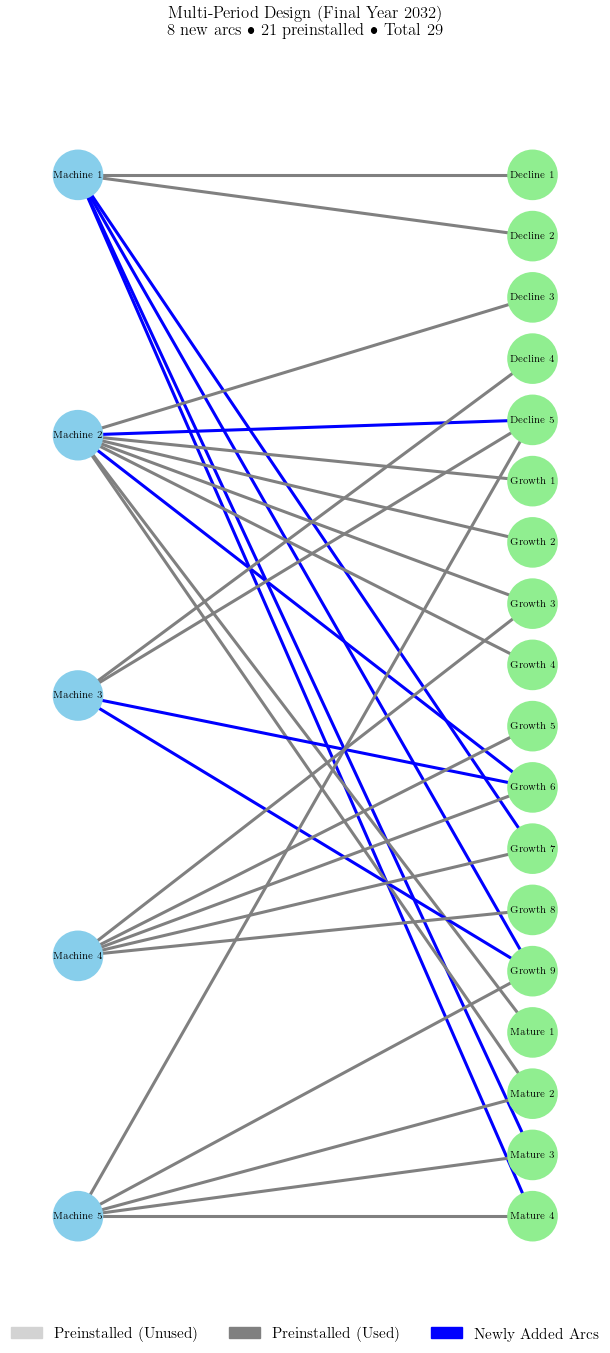

In [55]:
# =============================================================================
# Multi-Period Bipartite Graph (Final Year Visualization with Summary Counts)
# =============================================================================

# --- Build and draw bipartite graph ------------------------------------------
B_final = nx.Graph()
B_final.add_nodes_from(M, bipartite=0)
B_final.add_nodes_from(P, bipartite=1)
B_final.add_edges_from(all_display_edges)

# --- Vertical alignment logic (top/bottom aligned) ---------------------------
n_M = len(M)
n_P = len(P)
max_len = max(n_M, n_P)
y_positions = list(reversed(range(max_len)))  # e.g., [4,3,2,1,0]

def evenly_spaced_positions(n, max_len):
    if n == 1:
        return [y_positions[0]]
    return [
        y_positions[0] - k * (y_positions[0] - y_positions[-1]) / (n - 1)
        for k in range(n)
    ]

y_M = evenly_spaced_positions(n_M, max_len)
y_P = evenly_spaced_positions(n_P, max_len)

pos = {i: (0, y) for i, y in zip(M, y_M)}
pos.update({j: (1, y) for j, y in zip(P, y_P)})  # ✅ fixed missing parenthesis

# --- Edge colors and widths ---------------------------------------------------
edge_colors, edge_widths = [], []
for e in B_final.edges():
    if e in new_edges_multi:
        edge_colors.append("blue")
        edge_widths.append(2.2)
    elif e in shared_edges_multi:
        edge_colors.append("gray")
        edge_widths.append(2.2)
    elif e in baseline_edges:
        edge_colors.append("lightgray")
        edge_widths.append(2.2)
    else:
        edge_colors.append("lightgray")
        edge_widths.append(2.2)

# --- Plot --------------------------------------------------------------------
plt.figure(figsize=(5.5, max(2.5, 0.7 * max_len)))

nx.draw(
    B_final,
    pos,
    with_labels=True,
    node_color=["skyblue"] * len(M) + ["lightgreen"] * len(P),
    node_size=1200,
    edge_color=edge_colors,
    width=edge_widths,
    linewidths=1.8,
    font_size=7,
    font_weight="bold",
)

# --- Dynamic title with summary counts ---------------------------------------
plt.title(
    f"Multi-Period Design (Final Year {final_year})\n"
    f"{n_new_arcs} new arcs • {n_gray_arcs} preinstalled • Total {n_total_arcs}",
    fontsize=12,
    pad=22,
)
plt.axis("off")

# --- Legend (centered below) --------------------------------------------------
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color="lightgray", label="Preinstalled (Unused)"),
    mpatches.Patch(color="gray", label="Preinstalled (Used)"),
    mpatches.Patch(color="blue", label="Newly Added Arcs"),
]

plt.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    frameon=False,
    fontsize=11,
)

plt.subplots_adjust(left=0.05, right=0.95, top=0.9, bottom=0.1)
plt.show()


In [56]:
print('profit_term',profit_term.getValue())
print('opex',opex.getValue())
print('capex_M',capex_M.getValue())
print('capex_A',capex_A.getValue())

profit_term 194036787.38727537
opex 30500370.259902023
capex_M 0.0
capex_A 7128310.39234937


In [57]:
# c_ist[('Resource 1', 1, 10)]

In [58]:
# -----------------------------------------------------------------------------
# Start-period two-stage stochastic program
# -----------------------------------------------------------------------------

base_year = min(T_I)
t_theta = max(T_I)
T_V_max = max(T_V)

m = gp.Model("Flexibility-Investment Start-Period Two-Stage")

m_i    = m.addVars(M, vtype=GRB.BINARY, name="m")
a_ij   = m.addVars(M, P, vtype=GRB.BINARY, name="a")
u_i    = m.addVars(M, vtype=GRB.BINARY, name="u")
x_ijst = m.addVars(M, P, S, T_V, vtype=GRB.CONTINUOUS, lb=0.0, name="x")
y_ijs  = m.addVars(M, P, S, lb=0.0, ub=1.0, name="y")

disc = lambda t: 1.0 / (1.0 + r) ** ((t - base_year) + 1)

profit_term = gp.quicksum(
    disc(t) * π_s[s] * p_ij[i, j] * x_ijst[i, j, s, t]
    for i, j, s, t in itertools.product(M, P, S, T_V)
)

opex_coeff_i = {}
for i in M:
    life_end = min(base_year + L_i[i] - 1, T_V_max)
    opex_coeff_i[i] = (
        sum(disc(t) * f_i[i] for t in range(base_year, life_end + 1))
        if life_end >= base_year else 0.0
    )
opex = gp.quicksum(opex_coeff_i[i] * u_i[i] for i in M)

capex_M = gp.quicksum(g_i[i] * u_i[i] for i in M)
capex_A = gp.quicksum(
    h_ij[i, j] * a_ij[i, j]
    for i, j in itertools.product(M, P)
)

m.setObjective(profit_term - opex - capex_M - capex_A, GRB.MAXIMIZE)

m.addConstrs((m_i[i] == u_i[i] for i in M), name="startup")
m.addConstrs(
    (a_ij[i, j] <= m_i[i] for i in M for j in P),
    name="arc_machine",
)

# Existing qualifications are available whenever the existing machine is active.
m.addConstrs(
    (a_ij[i, j] == m_i[i] for i, j in pre_installed_arcs),
    name="preinstalled_capability",
)

for i in M:
    life_end = base_year + L_i[i] - 1
    for s in S:
        for t in T_V:
            if t > life_end:
                m.addConstr(
                    gp.quicksum(x_ijst[i, j, s, t] for j in P) <= 0.0,
                    name=f"life_capacity_{i}_{s}_{t}",
                )

m.addConstrs(
    (
        gp.quicksum(x_ijst[i, j, s, t] for i in M)
        <= d_j_s_t[j, s, t]
        for j, s, t in itertools.product(P, S, T_V)
    ),
    name="demand",
)
m.addConstrs(
    (
        gp.quicksum(x_ijst[i, j, s, t] for j in P) / throughput
        <= c_ist[i, s, t] * m_i[i]
        for i, s, t in itertools.product(M, S, T_V)
    ),
    name="capacity",
)
m.addConstrs(
    (
        x_ijst[i, j, s, t] / throughput
        <= c_ist[i, s, t] * a_ij[i, j]
        for i, j, s, t in itertools.product(M, P, S, T_V)
    ),
    name="arc_link",
)

m.addConstrs(
    (
        x_ijst[i, j, s, t_theta]
        <= y_ijs[i, j, s] * d_j_s_t[j, s, t_theta]
        for i, j, s in itertools.product(M, P, S)
    ),
    name="share_def",
)
m.addConstrs(
    (
        x_ijst[i, j, s, t]
        <= y_ijs[i, j, s] * d_j_s_t[j, s, t]
        for i, j, s, t in itertools.product(M, P, S, T_V)
        if t > t_theta
    ),
    name="share_frozen",
)
m.addConstrs(
    (
        gp.quicksum(y_ijs[i, j, s] for i in M) == 1.0
        for j, s in itertools.product(P, S)
    ),
    name="share_sum",
)

m.Params.OutputFlag = 1
m.Params.Threads = 8
m.optimize()

if m.Status != GRB.OPTIMAL:
    raise RuntimeError(
        f"Start-period planning model did not solve to optimality; status={m.Status}"
    )


Set parameter OutputFlag to value 1
Set parameter Threads to value 8
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 24.6.0 24G720)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
Threads  8

Optimize a model with 50716 rows, 40600 columns and 158967 nonzeros (Max)
Model fingerprint: 0x7657fc10
Model has 36074 linear objective coefficients
Variable types: 40500 continuous, 100 integer (100 binary)
Coefficient statistics:
  Matrix range     [1e+00, 2e+04]
  Objective range  [1e+00, 1e+07]
  Bounds range     [1e+00, 1e+00]
  RHS range        [4e-02, 2e+04]

Found heuristic solution: objective -0.0000000
Presolve removed 21177 rows and 17478 columns
Presolve time: 0.24s
Presolved: 29539 rows, 23122 columns, 93412 nonzeros
Variable types: 23068 continuous, 54 integer (54 binary)

Root relaxation: objective 1.509250e+08, 26662 iterations, 2.13 seconds (2.12 work units)

    Nodes    |    Cur

In [59]:
# =============================================================================
# Start-Period Arc & Machine Summary (single-period, calendar-safe)
# =============================================================================

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------------------------------------------------------
# 0) Load baseline arcs from IJ.csv (preinstalled)
# -----------------------------------------------------------------------------
IJ_base = pd.read_csv("IJ.csv").rename(columns={"Machine": "i", "Product": "j"})
IJ_base = IJ_base[IJ_base["i"].isin(M) & IJ_base["j"].isin(P)]  # ensure valid subset
pre_installed_arcs = list(map(tuple, IJ_base[["i", "j"]].drop_duplicates().to_numpy()))
baseline_edges = set(pre_installed_arcs)

# -----------------------------------------------------------------------------
# 1) Extract model solution (start-period)
# -----------------------------------------------------------------------------
a_ij_two = {(i, j): var.X for (i, j), var in a_ij.items()}
m_i_two  = {i: var.X for i, var in m_i.items()}
u_i_two  = {i: var.X for i, var in u_i.items()}

# Arcs actively installed in the optimized design
selected_edges = {(i, j) for (i, j), val in a_ij_two.items() if val > 0.5}

Start-Period Model Summary
  New arcs (red): 7
  Preinstalled arcs (gray): 21
  Total arcs shown (red + gray): 28


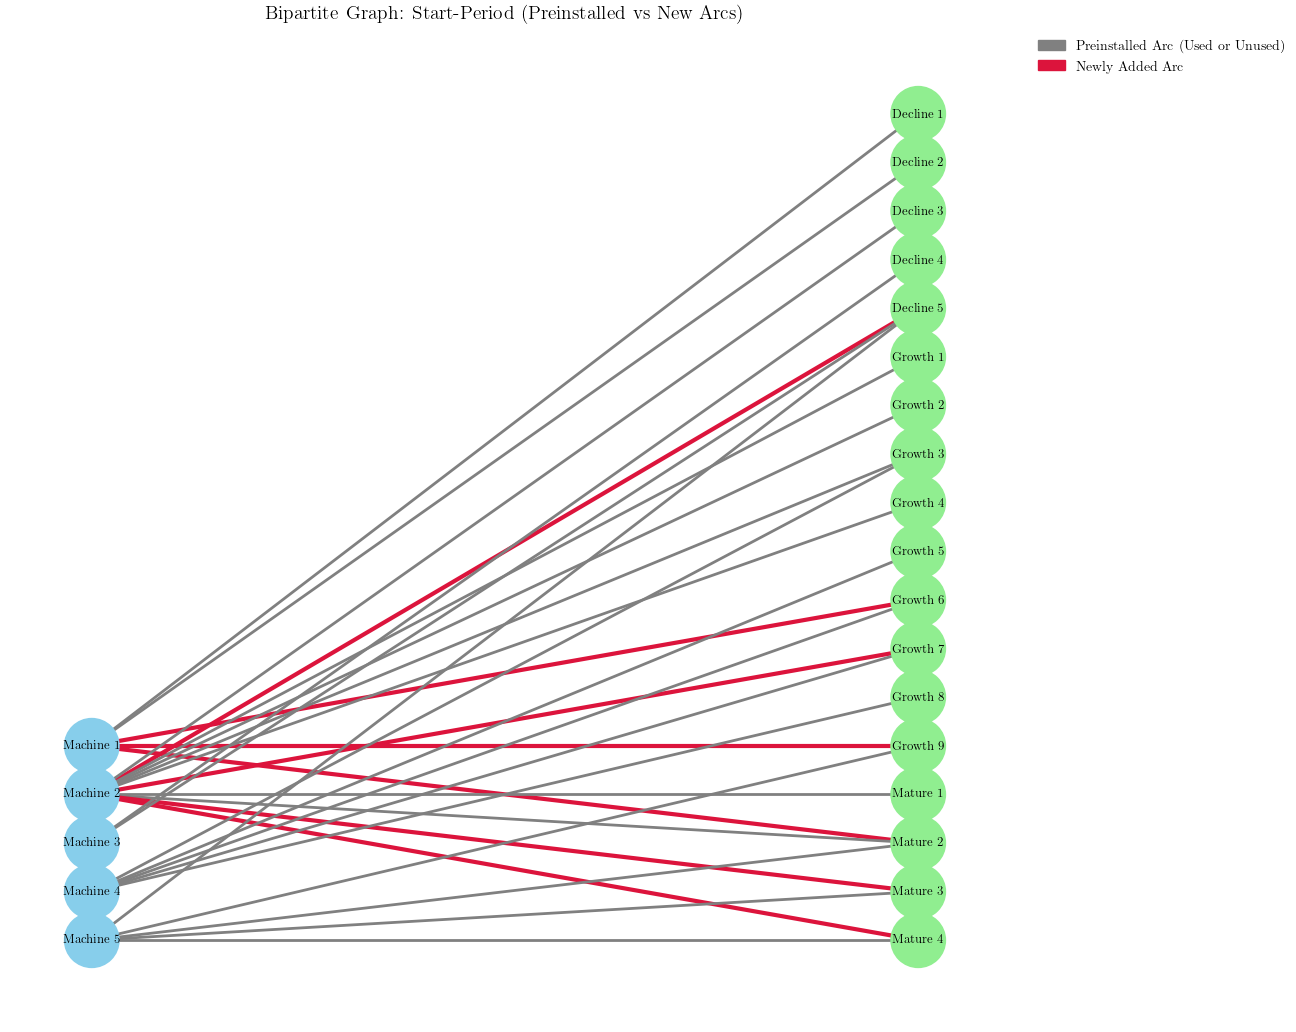

In [60]:


# -----------------------------------------------------------------------------
# 2) Identify new vs. preinstalled arcs
# -----------------------------------------------------------------------------
new_edges_start  = selected_edges - baseline_edges
shared_edges_start = selected_edges & baseline_edges
all_display_edges = baseline_edges | selected_edges  # show both

# Counts
n_new_arcs   = len(new_edges_start)
n_gray_arcs  = len(baseline_edges)  # includes used + unused
n_total_arcs = n_new_arcs + n_gray_arcs

# Active machine count
n_machines_single = int(sum(val > 0.5 for val in m_i_two.values()))

# Summary
print("Start-Period Model Summary")
print(f"  New arcs (red): {n_new_arcs}")
print(f"  Preinstalled arcs (gray): {n_gray_arcs}")
print(f"  Total arcs shown (red + gray): {n_total_arcs}")
#print(f"  Active machines: {n_machines_single}")

# -----------------------------------------------------------------------------
# 3) Build bipartite graph
# -----------------------------------------------------------------------------
B_final = nx.Graph()
B_final.add_nodes_from(M, bipartite=0)
B_final.add_nodes_from(P, bipartite=1)
B_final.add_edges_from(all_display_edges)

# consistent left-right layout
pos = {i: (0, len(M) - k - 1) for k, i in enumerate(M)}
pos.update({j: (1, len(P) - k - 1) for k, j in enumerate(P)})

# -----------------------------------------------------------------------------
# 4) Edge coloring and widths
# -----------------------------------------------------------------------------
edge_colors, edge_widths = [], []
for e in B_final.edges():
    if e in new_edges_start:
        edge_colors.append("crimson")   # newly added
        edge_widths.append(3.0)
    elif e in shared_edges_start:
        edge_colors.append("gray")      # preinstalled and used
        edge_widths.append(2.0)
    elif e in baseline_edges:
        edge_colors.append("gray")      # preinstalled but unused
        edge_widths.append(2.0)
    else:
        edge_colors.append("lightgray")
        edge_widths.append(1.5)

# -----------------------------------------------------------------------------
# 5) Plot
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 10))
nx.draw(
    B_final,
    pos,
    with_labels=True,
    node_color=["skyblue"] * len(M) + ["lightgreen"] * len(P),
    node_size=1500,
    edge_color=edge_colors,
    width=edge_widths,
    linewidths=1.5,
    font_size=9,
)
plt.title("Bipartite Graph: Start-Period (Preinstalled vs New Arcs)", fontsize=14)
plt.axis("off")

# Legend
legend_handles = [
    mpatches.Patch(color="gray", label="Preinstalled Arc (Used or Unused)"),
    mpatches.Patch(color="crimson", label="Newly Added Arc"),
]
plt.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
)

# small margin instead of tight layout
plt.subplots_adjust(left=0.05, right=0.85, top=0.92, bottom=0.05)
plt.show()


### Network Plots

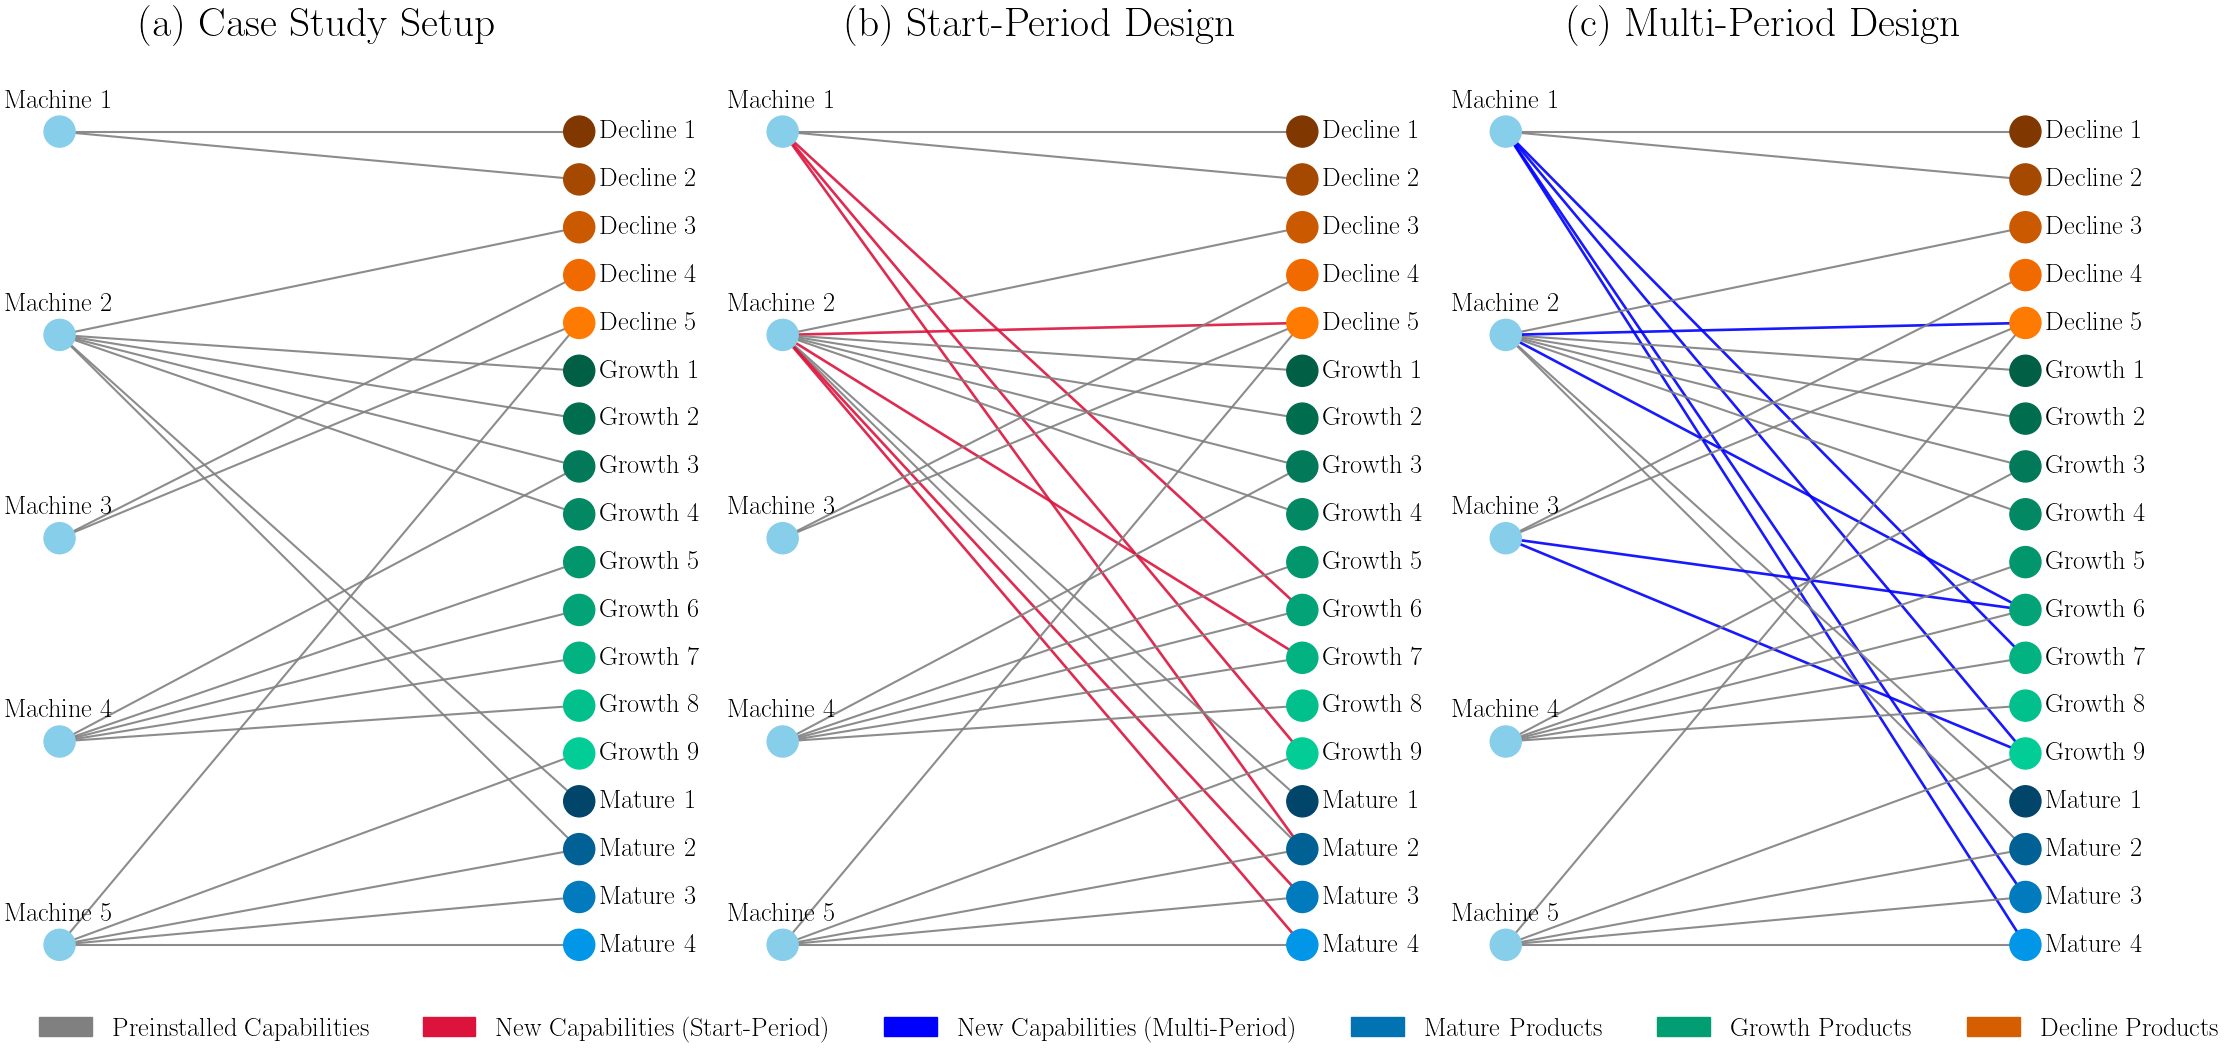

In [61]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

# =============================================================================
# 1) Load and normalize baseline data
# =============================================================================
IJ = pd.read_csv("IJ.csv")
IJ = IJ.rename(columns={"Machine": "i", "Product": "j"})
M = sorted(IJ["i"].unique())
P = sorted(IJ["j"].unique())
baseline_edges = set(map(tuple, IJ[["i", "j"]].drop_duplicates().to_numpy()))
pre_installed_arcs = list(baseline_edges)

# Lifecycle mapping
segment_to_lifecycle = {"Decline": "Decline", "Growth": "Growth", "Mature": "Mature"}
IJ["Lifecycle"] = IJ["Segment"].map(segment_to_lifecycle)

# =============================================================================
# 2) Color palette (same as demand+profit chart)
# =============================================================================
base_palette = sns.color_palette("colorblind", 6)
lifecycle_order = ["Mature", "Growth", "Decline"]
base_hues = {
    "Mature": base_palette[0],   # blue
    "Growth": base_palette[2],   # green
    "Decline": base_palette[3],  # orange
}

def generate_shades(base_color, n):
    base = np.array(mcolors.to_rgb(base_color), dtype=float)
    factors = np.linspace(0.6, 1.3, n)
    return [tuple(np.clip(base * f, 0, 1)) for f in factors]

# Assign lifecycle-based colors per product
product_colors = {}
for lifecycle in lifecycle_order:
    seg_products = IJ[IJ["Lifecycle"] == lifecycle]["j"].unique()
    shades = generate_shades(base_hues[lifecycle], len(seg_products))
    for j, c in zip(seg_products, shades):
        product_colors[j] = c

# =============================================================================
# 3) Load start-period and multi-period results (if available)
# =============================================================================
try:
    selected_edges_start = {(i, j) for (i, j), val in a_ij_two.items() if val > 0.5}
    new_edges_start = selected_edges_start - baseline_edges
    all_display_edges_start = baseline_edges | selected_edges_start
except NameError:
    selected_edges_start = baseline_edges
    new_edges_start = set()
    all_display_edges_start = baseline_edges

try:
    final_arcs_multi = [
        (i, j) for (i, j, t), val in a_ijt_multi.items() if t == max(T_I) and val > 0.005
    ]
    new_edges_multi = set(final_arcs_multi) - baseline_edges
    all_display_edges_multi = baseline_edges | set(final_arcs_multi)
except NameError:
    new_edges_multi = set()
    all_display_edges_multi = baseline_edges

# =============================================================================
# 4) Consistent vertical alignment
# =============================================================================
n_M = len(M)
n_P = len(P)
max_len = max(n_M, n_P)
y_positions = list(reversed(range(max_len)))

def evenly_spaced_positions(n, max_len):
    if n == 1:
        return [y_positions[0]]
    return [y_positions[0] - k * (y_positions[0] - y_positions[-1]) / (n - 1) for k in range(n)]

y_M = evenly_spaced_positions(n_M, max_len)
y_P = evenly_spaced_positions(n_P, max_len)
pos = {i: (0, y) for i, y in zip(M, y_M)}
pos.update({j: (1, y) for j, y in zip(P, y_P)})

# =============================================================================
# 5) Figure setup (1×3 layout)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(25, 12))
titles = [
    "(a) Case Study Setup",
    "(b) Start-Period Design",
    f"(c) Multi-Period Design"
]

# -----------------------------------------------------------------------------
# Helper to draw networks with external labels
# -----------------------------------------------------------------------------
def draw_bipartite_graph(G, ax, edges_new=set(), new_color="crimson"):
    edge_colors = [new_color if e in edges_new else "gray" for e in G.edges()]
    edge_widths = [1.9 if e in edges_new else 1.5 for e in G.edges()]
    node_colors = ["skyblue" if n in M else product_colors.get(n, "lightgreen") for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, nodelist=G.nodes(), node_color=node_colors, node_size=500, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=G.edges(), edge_color=edge_colors,
                           width=edge_widths, ax=ax, alpha=0.9)

    # Draw labels outside nodes
    label_offset = 0.04  # horizontal offset
    for node, (x, y) in pos.items():
        if node in M:  # machine nodes → left
            ax.text(x, y+0.4, node, ha="center", va="bottom", fontsize=19, fontweight="bold")
        else:           # product nodes → right
            ax.text(x + label_offset, y, node, ha="left", va="center", fontsize=19, fontweight="bold")

    ax.axis("off")

# -----------------------------------------------------------------------------
# (a) Baseline
# -----------------------------------------------------------------------------
B1 = nx.Graph()
B1.add_nodes_from(M + P)
B1.add_edges_from(baseline_edges)
draw_bipartite_graph(B1, axes[0])
axes[0].set_title(titles[0], fontsize=30)

# -----------------------------------------------------------------------------
# (b) Start-Period
# -----------------------------------------------------------------------------
B2 = nx.Graph()
B2.add_nodes_from(M + P)
B2.add_edges_from(all_display_edges_start)
draw_bipartite_graph(B2, axes[1], edges_new=new_edges_start, new_color="crimson")
axes[1].set_title(titles[1], fontsize=30)

# -----------------------------------------------------------------------------
# (c) Multi-Period
# -----------------------------------------------------------------------------
B3 = nx.Graph()
B3.add_nodes_from(M + P)
B3.add_edges_from(all_display_edges_multi)
draw_bipartite_graph(B3, axes[2], edges_new=new_edges_multi, new_color="blue")
axes[2].set_title(titles[2], fontsize=30)

# =============================================================================
# 6) Legend on the right side
# =============================================================================
legend_handles = [
    mpatches.Patch(color="gray", label="Preinstalled Capabilities"),
    mpatches.Patch(color="crimson", label="New Capabilities (Start-Period)"),
    mpatches.Patch(color="blue", label="New Capabilities (Multi-Period)"),
    mpatches.Patch(color=base_hues["Mature"], label="Mature Products"),
    mpatches.Patch(color=base_hues["Growth"], label="Growth Products"),
    mpatches.Patch(color=base_hues["Decline"], label="Decline Products"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, 0.05),
    frameon=False,
    fontsize=19,
)

plt.subplots_adjust(left=0.05, right=0.88, top=0.9, bottom=0.08, wspace=0.15)
plt.savefig("networkplots.pdf", bbox_inches="tight")
plt.show()


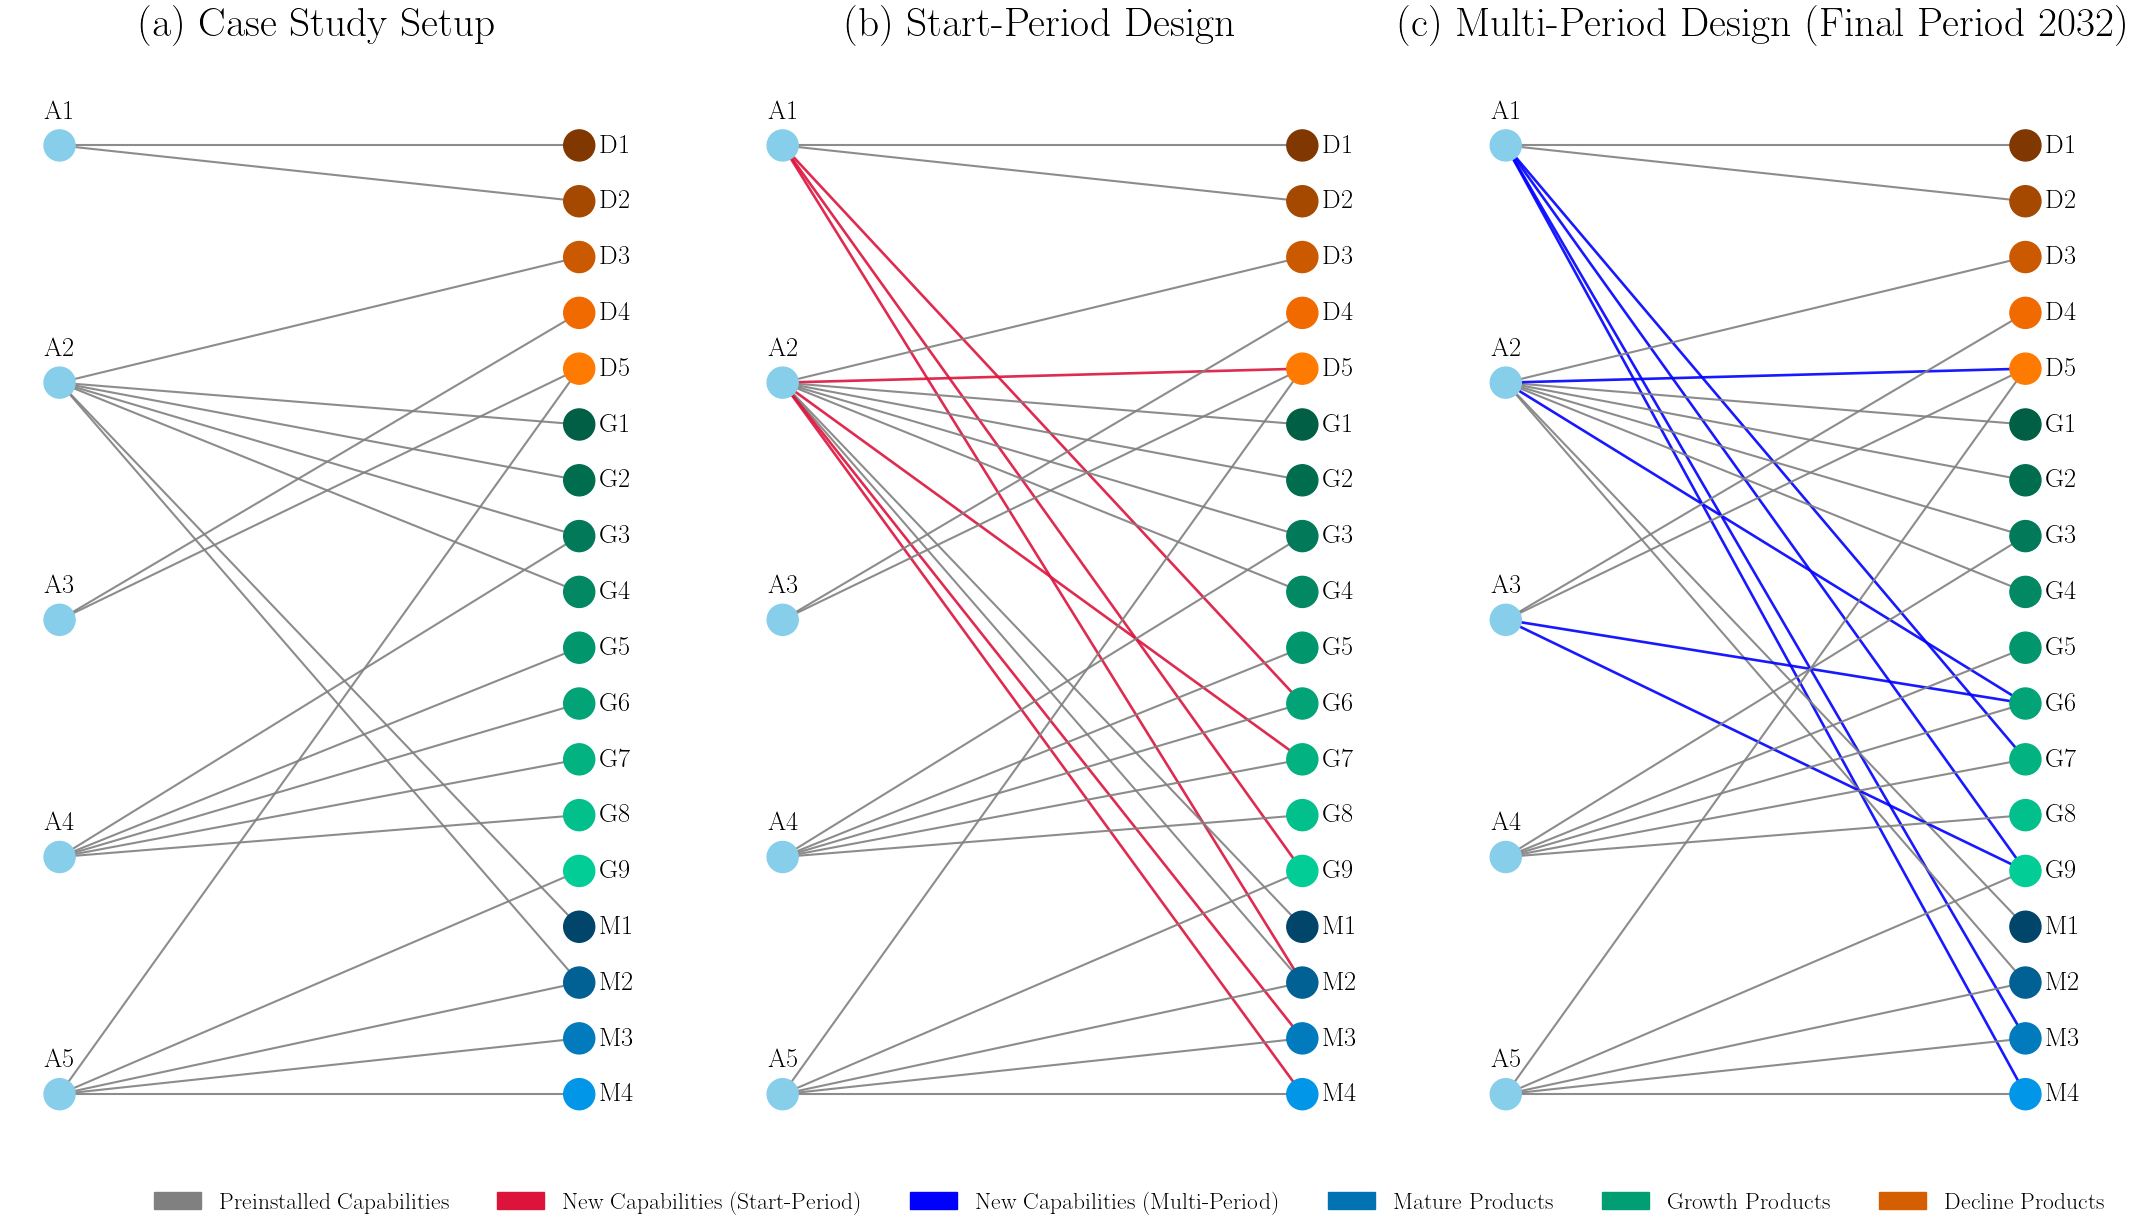

In [62]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np

# =============================================================================
# 1) Load and normalize baseline data
# =============================================================================
IJ = pd.read_csv("IJ.csv")
IJ = IJ.rename(columns={"Machine": "i", "Product": "j"})
M = sorted(IJ["i"].unique())
P = sorted(IJ["j"].unique())

baseline_edges = set(map(tuple, IJ[["i", "j"]].drop_duplicates().to_numpy()))
pre_installed_arcs = list(baseline_edges)

# Lifecycle
segment_to_lifecycle = {"Decline": "Decline", "Growth": "Growth", "Mature": "Mature"}
IJ["Lifecycle"] = IJ["Segment"].map(segment_to_lifecycle)

# =============================================================================
# LABEL MAPPINGS
# =============================================================================

# Machine labels A1, A2, ...
machine_labels = {m: f"A{idx+1}" for idx, m in enumerate(M)}

# Products split by lifecycle
decline_products = [j for j in P if IJ.loc[IJ["j"] == j, "Lifecycle"].iloc[0] == "Decline"]
growth_products  = [j for j in P if IJ.loc[IJ["j"] == j, "Lifecycle"].iloc[0] == "Growth"]
mature_products  = [j for j in P if IJ.loc[IJ["j"] == j, "Lifecycle"].iloc[0] == "Mature"]

decline_labels = {j: f"D{idx+1}" for idx, j in enumerate(decline_products)}
growth_labels  = {j: f"G{idx+1}" for idx, j in enumerate(growth_products)}
mature_labels  = {j: f"M{idx+1}" for idx, j in enumerate(mature_products)}

product_labels = {**decline_labels, **growth_labels, **mature_labels}

# =============================================================================
# 2) Color palette
# =============================================================================
base_palette = sns.color_palette("colorblind", 6)
lifecycle_order = ["Mature", "Growth", "Decline"]
base_hues = {
    "Mature": base_palette[0],
    "Growth": base_palette[2],
    "Decline": base_palette[3],
}

def generate_shades(base_color, n):
    base = np.array(mcolors.to_rgb(base_color), dtype=float)
    factors = np.linspace(0.6, 1.3, n)
    return [tuple(np.clip(base * f, 0, 1)) for f in factors]

product_colors = {}
for lifecycle in lifecycle_order:
    seg_products = IJ[IJ["Lifecycle"] == lifecycle]["j"].unique()
    shades = generate_shades(base_hues[lifecycle], len(seg_products))
    for j, c in zip(seg_products, shades):
        product_colors[j] = c

# =============================================================================
# 3) Load start-period and multi-period results (if available)
# =============================================================================
try:
    selected_edges_start = {(i, j) for (i, j), val in a_ij_two.items() if val > 0.5}
    new_edges_start = selected_edges_start - baseline_edges
    all_display_edges_start = baseline_edges | selected_edges_start
except NameError:
    selected_edges_start = baseline_edges
    new_edges_start = set()
    all_display_edges_start = baseline_edges

try:
    final_arcs_multi = [
        (i, j) for (i, j, t), val in a_ijt_multi.items() if t == max(T_I) and val > 0.005
    ]
    new_edges_multi = set(final_arcs_multi) - baseline_edges
    all_display_edges_multi = baseline_edges | set(final_arcs_multi)
except NameError:
    new_edges_multi = set()
    all_display_edges_multi = baseline_edges

# =============================================================================
# 4) Node positions
# =============================================================================
n_M = len(M)
n_P = len(P)
max_len = max(n_M, n_P)
y_positions = list(reversed(range(max_len)))

def evenly_spaced_positions(n, max_len):
    if n == 1:
        return [y_positions[0]]
    return [y_positions[0] - k * (y_positions[0] - y_positions[-1]) / (n - 1) for k in range(n)]

y_M = evenly_spaced_positions(n_M, max_len)
y_P = evenly_spaced_positions(n_P, max_len)

pos = {i: (0, y) for i, y in zip(M, y_M)}
pos.update({j: (1, y) for j, y in zip(P, y_P)})

# =============================================================================
# 5) Figure setup (1×3)
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(25, 14))

titles = [
    "(a) Case Study Setup",
    "(b) Start-Period Design",
    f"(c) Multi-Period Design (Final Period {max(T_I) if 'T_I' in locals() else ''})"
]

# =============================================================================
# Draw graph helper
# =============================================================================
def draw_bipartite_graph(G, ax, edges_new=set(), new_color="crimson"):
    edge_colors = [new_color if e in edges_new else "gray" for e in G.edges()]
    edge_widths = [1.9 if e in edges_new else 1.5 for e in G.edges()]
    node_colors = ["skyblue" if n in M else product_colors.get(n, "lightgreen") for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, nodelist=G.nodes(),
                           node_color=node_colors, node_size=500, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=G.edges(),
                           edge_color=edge_colors, width=edge_widths, ax=ax, alpha=0.9)

    # === Updated label drawing using A#, D#, G#, M# ===
    label_offset = 0.04
    for node, (x, y) in pos.items():
        if node in M:
            label = machine_labels[node]   # A1, A2, ...
            ax.text(x, y+0.4, label, ha="center", va="bottom",
                    fontsize=19, fontweight="bold")
        else:
            label = product_labels[node]   # D1 / G1 / M1
            ax.text(x + label_offset, y, label, ha="left", va="center",
                    fontsize=19, fontweight="bold")

    ax.axis("off")

# =============================================================================
# (a) Baseline
# =============================================================================
B1 = nx.Graph()
B1.add_nodes_from(M + P)
B1.add_edges_from(baseline_edges)
draw_bipartite_graph(B1, axes[0])
axes[0].set_title(titles[0], fontsize=30)

# =============================================================================
# (b) Start-period
# =============================================================================
B2 = nx.Graph()
B2.add_nodes_from(M + P)
B2.add_edges_from(all_display_edges_start)
draw_bipartite_graph(B2, axes[1], edges_new=new_edges_start, new_color="crimson")
axes[1].set_title(titles[1], fontsize=30)

# =============================================================================
# (c) Multi-period
# =============================================================================
B3 = nx.Graph()
B3.add_nodes_from(M + P)
B3.add_edges_from(all_display_edges_multi)
draw_bipartite_graph(B3, axes[2], edges_new=new_edges_multi, new_color="blue")
axes[2].set_title(titles[2], fontsize=30)

# =============================================================================
# Legend
# =============================================================================
legend_handles = [
    mpatches.Patch(color="gray", label="Preinstalled Capabilities"),
    mpatches.Patch(color="crimson", label="New Capabilities (Start-Period)"),
    mpatches.Patch(color="blue", label="New Capabilities (Multi-Period)"),
    mpatches.Patch(color=base_hues["Mature"], label="Mature Products"),
    mpatches.Patch(color=base_hues["Growth"], label="Growth Products"),
    mpatches.Patch(color=base_hues["Decline"], label="Decline Products"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, 0.05),
    frameon=False,
    fontsize=17,
)

plt.subplots_adjust(left=0.05, right=0.88, top=0.9, bottom=0.08, wspace=0.15)
plt.savefig("networkplots3.pdf", bbox_inches="tight")
plt.show()


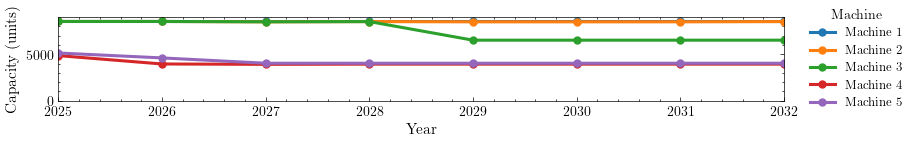

In [63]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Load and clean data
# ============================================================
cist = pd.read_csv("c_ist.csv")

# Standardize column names
cist.columns = [col.strip() for col in cist.columns]
cist = cist.rename(columns={
    "Machine": "i",
    "Year": "t",
    "Capacity": "capacity"
})

# Ensure numeric types
cist["t"] = pd.to_numeric(cist["t"], errors="coerce")
cist["capacity"] = pd.to_numeric(cist["capacity"], errors="coerce")
cist = cist.dropna(subset=["i", "t", "capacity"])

# ============================================================
# Plot with Matplotlib only
# ============================================================
plt.figure(figsize=(11, 1.5))

# Colorblind-friendly palette
colorblind_colors = plt.cm.tab10.colors
machines = sorted(cist["i"].unique())

for idx, m in enumerate(machines):
    subset = cist[cist["i"] == m].sort_values("t")
    plt.plot(
        subset["t"], subset["capacity"],
        label=m,
        color=colorblind_colors[idx % len(colorblind_colors)],
        linewidth=2.2,
        marker="o",
        markersize=5
    )

# Formatting
#plt.title("Machine Capacity", fontsize=13, weight="bold")
plt.xlabel("Year", fontsize=11)
plt.ylabel("Capacity (units)", fontsize=11)
plt.xlim(2025, 2032)
plt.ylim(0, 9000)
plt.grid(False)

# Legend outside to the right
plt.legend(
    title="Machine",
    fontsize=9,
    title_fontsize=10,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # leave space for legend
plt.savefig("machine_capacity.pdf", bbox_inches="tight")
plt.show()


### Model Evaluation

In [64]:
# =============================================================================
# Independent out-of-sample evaluation scenarios
# =============================================================================

(
    S,
    π_s,
    sampled_scenarios,
    scenario_assign_df,
    d_j_s_t,
    d_j_s_t_df,
    c_ist,
    cap_df,
) = build_case_study_scenarios(EVALUATION_N_SAMPLES, EVALUATION_SEED)

EVALUATION_OUTPUT_DIR = DATA_DIR / "saa_outputs" / "evaluation"
save_case_study_scenarios(
    EVALUATION_OUTPUT_DIR, scenario_assign_df, d_j_s_t_df, cap_df
)
pd.DataFrame(
    [(i, j, v) for (i, j), v in p_ij.items()],
    columns=["i", "j", "p_ij"],
).to_csv(EVALUATION_OUTPUT_DIR / "p_ij.csv", index=False)

growth_draws_eval = [
    sampled_scenarios[s][j]
    for s in S
    for j in growth_products
]
empirical_launch_rate_eval = (
    np.mean([state != "NoLaunch" for state in growth_draws_eval])
    if growth_draws_eval else np.nan
)

print(f"Evaluation scenarios: {len(S)}")
print(f"Sum pi_s: {sum(π_s.values()):.6f}")
print(f"Independent evaluation seed: {EVALUATION_SEED}")
print(f"Empirical Growth launch rate in evaluation sample: {empirical_launch_rate_eval:.3f}")


Evaluation scenarios: 500
Sum pi_s: 1.000000
Independent evaluation seed: 456
Empirical Growth launch rate in evaluation sample: 0.800


In [65]:
# =============================================================================
# Start-period evaluation on the independent 300-scenario sample
# =============================================================================

base_year = min(T_I)
t_theta = max(T_I)
T_V_max = max(T_V)

disc = lambda t: 1.0 / (1.0 + r) ** ((t - base_year) + 1)

m = gp.Model("Flexibility-Investment Start-Period Evaluation")
x_ijst = m.addVars(M, P, S, T_V, lb=0.0, vtype=GRB.CONTINUOUS, name="x")
y_ijs  = m.addVars(M, P, S, lb=0.0, ub=1.0, vtype=GRB.CONTINUOUS, name="y")

profit_term = gp.quicksum(
    disc(t) * π_s[s] * p_ij[i, j] * x_ijst[i, j, s, t]
    for i, j, s, t in itertools.product(M, P, S, T_V)
)

opex_coeff_i = {}
for i in M:
    life_end = min(base_year + L_i[i] - 1, T_V_max)
    opex_coeff_i[i] = (
        sum(disc(t) * f_i[i] for t in range(base_year, life_end + 1))
        if life_end >= base_year else 0.0
    )
opex = gp.quicksum(
    opex_coeff_i[i] * float(u_i_two[i])
    for i in M
)

capex_M = gp.quicksum(
    g_i[i] * float(u_i_two[i])
    for i in M
)
capex_A = gp.quicksum(
    h_ij[i, j] * float(a_ij_two[i, j])
    for i, j in itertools.product(M, P)
)

m.setObjective(profit_term - opex - capex_M - capex_A, GRB.MAXIMIZE)

for i in M:
    life_end = base_year + L_i[i] - 1
    for s in S:
        for t in T_V:
            if t > life_end:
                m.addConstr(
                    gp.quicksum(x_ijst[i, j, s, t] for j in P) <= 0.0,
                    name=f"life_capacity_{i}_{s}_{t}",
                )

m.addConstrs(
    (
        gp.quicksum(x_ijst[i, j, s, t] for i in M)
        <= d_j_s_t[j, s, t]
        for j, s, t in itertools.product(P, S, T_V)
    ),
    name="demand",
)
m.addConstrs(
    (
        gp.quicksum(x_ijst[i, j, s, t] for j in P) / throughput
        <= c_ist[i, s, t] * float(m_i_two[i])
        for i, s, t in itertools.product(M, S, T_V)
    ),
    name="capacity",
)
m.addConstrs(
    (
        x_ijst[i, j, s, t] / throughput
        <= c_ist[i, s, t] * float(a_ij_two[i, j])
        for i, j, s, t in itertools.product(M, P, S, T_V)
    ),
    name="arc_link",
)

m.addConstrs(
    (
        x_ijst[i, j, s, t_theta]
        <= y_ijs[i, j, s] * d_j_s_t[j, s, t_theta]
        for i, j, s in itertools.product(M, P, S)
    ),
    name="share_def",
)
m.addConstrs(
    (
        x_ijst[i, j, s, t]
        <= y_ijs[i, j, s] * d_j_s_t[j, s, t]
        for i, j, s, t in itertools.product(M, P, S, T_V)
        if t > t_theta
    ),
    name="share_frozen",
)
m.addConstrs(
    (
        gp.quicksum(y_ijs[i, j, s] for i in M) == 1.0
        for j, s in itertools.product(P, S)
    ),
    name="share_sum",
)

m.Params.OutputFlag = 1
m.Params.Threads = 8
m.optimize()

if m.Status != GRB.OPTIMAL:
    raise RuntimeError(
        f"Start-period evaluation LP did not solve to optimality; status={m.Status}"
    )


Set parameter OutputFlag to value 1
Set parameter Threads to value 8
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 24.6.0 24G720)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
Threads  8

Optimize a model with 506000 rows, 405000 columns and 1207330 nonzeros (Max)
Model fingerprint: 0xe64c04a0
Model has 360000 linear objective coefficients and an objective constant of 3.0429214219019759e+07
Coefficient statistics:
  Matrix range     [1e+00, 2e+04]
  Objective range  [1e-01, 9e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [4e-02, 2e+04]

Presolve removed 499816 rows and 381976 columns
Presolve time: 0.36s
Presolved: 6184 rows, 23024 columns, 27751 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 5.636e+03
 Factor NZ  : 1.430e+04 (roughly 12 MB of memory)
 Facto

In [66]:
single_period_profit = m.ObjVal

In [67]:
# =============================================================================
# Multi-period evaluation on the independent 300-scenario sample
# =============================================================================

base_year = min(T_I)
t_theta = max(T_I)
T_V_max = max(T_V)

disc = lambda t: 1.0 / (1.0 + r) ** ((t - base_year) + 1)

m = gp.Model("Flexibility-Investment Multi-Period Evaluation")
x_ijst = m.addVars(M, P, S, T_V, lb=0.0, vtype=GRB.CONTINUOUS, name="x")
y_ijs  = m.addVars(M, P, S, lb=0.0, ub=1.0, name="y")

profit_term = gp.quicksum(
    disc(t) * π_s[s] * p_ij[i, j] * x_ijst[i, j, s, t]
    for i, j, s, t in itertools.product(M, P, S, T_V)
)

opex_coeff = {}
for i in M:
    for tau in T_I:
        life_end = min(tau + L_i[i] - 1, T_V_max)
        opex_coeff[i, tau] = (
            f_i[i] * sum(disc(t) for t in range(tau, life_end + 1))
            if tau <= life_end else 0.0
        )
opex = gp.quicksum(
    opex_coeff[i, tau] * float(u_it_multi[i, tau])
    for i in M for tau in T_I
)

capex_M = gp.quicksum(
    g_i[i] / (1.0 + r) ** (tau - base_year) * float(u_it_multi[i, tau])
    for i in M for tau in T_I
)

capex_A = gp.LinExpr()
for i, j in itertools.product(M, P):
    for tau in T_I:
        prev = 0.0 if tau == base_year else float(a_ijt_multi.get((i, j, tau - 1), 0.0))
        curr = float(a_ijt_multi.get((i, j, tau), 0.0))
        capex_A += (
            h_ij[i, j] / (1.0 + r) ** (tau - base_year)
            * (curr - prev)
        )

m.setObjective(profit_term - opex - capex_M - capex_A, GRB.MAXIMIZE)

m.addConstrs(
    (
        gp.quicksum(x_ijst[i, j, s, t] for i in M)
        <= d_j_s_t[j, s, t]
        for j, s, t in itertools.product(P, S, T_V)
    ),
    name="demand",
)
m.addConstrs(
    (
        gp.quicksum(x_ijst[i, j, s, t] for j in P) / throughput
        <= c_ist[i, s, t]
        * (float(m_it_multi[i, t]) if t <= t_theta else float(m_it_multi[i, t_theta]))
        for i, s, t in itertools.product(M, S, T_V)
    ),
    name="capacity",
)
m.addConstrs(
    (
        x_ijst[i, j, s, t] / throughput
        <= c_ist[i, s, t]
        * (
            float(a_ijt_multi[i, j, t])
            if t <= t_theta
            else float(a_ijt_multi[i, j, t_theta])
        )
        for i, j, s, t in itertools.product(M, P, S, T_V)
    ),
    name="arc_link",
)

for i in M:
    for s in S:
        for t in T_V:
            if t > t_theta:
                alive = sum(
                    float(u_it_multi.get((i, tau), 0.0))
                    for tau in T_I
                    if (t - L_i[i] + 1) <= tau <= min(t, t_theta)
                )
                m.addConstr(
                    gp.quicksum(x_ijst[i, j, s, t] for j in P)
                    <= c_ist[i, s, t] * alive,
                    name=f"lifetime_{i}_{s}_{t}",
                )

m.addConstrs(
    (
        x_ijst[i, j, s, t_theta]
        <= y_ijs[i, j, s] * d_j_s_t[j, s, t_theta]
        for i, j, s in itertools.product(M, P, S)
    ),
    name="share_def",
)
m.addConstrs(
    (
        x_ijst[i, j, s, t]
        <= y_ijs[i, j, s] * d_j_s_t[j, s, t]
        for i, j, s, t in itertools.product(M, P, S, T_V)
        if t > t_theta
    ),
    name="share_frozen",
)
m.addConstrs(
    (
        gp.quicksum(y_ijs[i, j, s] for i in M) == 1.0
        for j, s in itertools.product(P, S)
    ),
    name="share_sum",
)

m.Params.OutputFlag = 1
m.Params.Threads = 8
m.optimize()

if m.Status != GRB.OPTIMAL:
    raise RuntimeError(
        f"Multi-period evaluation LP did not solve to optimality; status={m.Status}"
    )


Set parameter OutputFlag to value 1
Set parameter Threads to value 8
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 24.6.0 24G720)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
Threads  8

Optimize a model with 506000 rows, 405000 columns and 1207330 nonzeros (Max)
Model fingerprint: 0x36356b63
Model has 360000 linear objective coefficients and an objective constant of 3.7628680652251393e+07
Coefficient statistics:
  Matrix range     [1e+00, 2e+04]
  Objective range  [1e-01, 9e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [4e-02, 2e+04]

Presolve removed 488381 rows and 369245 columns
Presolve time: 0.28s
Presolved: 17619 rows, 35755 columns, 57997 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00s

Barrier statistics:
 AA' NZ     : 2.636e+04
 Factor NZ  : 1.200e+05 (roughly 22 MB of memory)
 Fact

In [68]:
multi_period_profit = m.ObjVal

In [69]:
VMPSP = multi_period_profit - single_period_profit

if single_period_profit>0:
    percent_VMPSP = VMPSP/single_period_profit
else:
    percent_VMPSP = 1




In [70]:
print("Multi-Period Profit", f"{multi_period_profit:,.0f}")
print("Single-Period Profit", f"{single_period_profit:,.0f}")

# print(n_arcs_mpts)
# print(n_arcs_spts)
# print(n_machines_mpts)
# print(n_machines_spts)
print(percent_VMPSP)
# print(percent_VMPLC)
print(multi_period_profit)
print(single_period_profit)

Multi-Period Profit 156,064,175
Single-Period Profit 148,317,753
0.052228551277974926
156064174.59823537
148317753.21881258


In [71]:
# ============================================
# Helpers to evaluate a fixed design on one scenario (CALENDAR-SAFE)
# ============================================

import gurobipy as gp
from gurobipy import GRB
import itertools

# Calendar anchors
base_year = min(T_I)          # e.g., 2025
t_theta   = max(T_I)
T_V_max   = max(T_V)

# Discount factor: end of calendar year t
def disc(t):
    return 1.0 / (1.0 + r) ** ((t - base_year) + 1)

def _fixed_costs_multi():
    """
    Present-value fixed costs for the MULTI-PERIOD design,
    using fixed schedules u_it_multi[(i,tau)] and a_ijt_multi[(i,j,tau)].
    Calendar-safe discounting and life windows.
    """
    # ---- OPEX: block costs per machine start tau, limited by life ----
    opex = 0.0
    for i in M:
        Li = L_i[i]
        for tau in T_I:  # tau is a calendar start year, e.g., 2025..2028
            life_end = min(tau + Li - 1, T_V_max)
            if tau <= life_end:
                coeff = f_i[i] * sum(disc(t) for t in range(tau, life_end + 1))
                opex += coeff * float(u_it_multi[(i, tau)])

    # ---- Machine CAPEX: paid at tau (discount by (tau - base_year)) ----
    capex_M = sum(
        (g_i[i] / (1.0 + r) ** (tau - base_year)) * float(u_it_multi[(i, tau)])
        for i in M for tau in T_I
    )

    # ---- Arc CAPEX: pay increments when arcs turn on at tau ----
    capex_A = 0.0
    for i in M:
        for j in P:
            prev = 0.0
            for tau in T_I:
                curr  = float(a_ijt_multi.get((i, j, tau), 0.0))
                delta = curr - prev
                if delta != 0.0:
                    capex_A += (h_ij[i, j] / (1.0 + r) ** (tau - base_year)) * delta
                prev = curr

    return opex, capex_M, capex_A


def _fixed_costs_start_at_zero(u_i, a_ij):
    """
    Present-value fixed costs when all investments happen at base_year
    (start-period / start-at-zero design).
    """
    # ---- OPEX: active from base_year to life_end ----
    opex = 0.0
    for i in M:
        life_end = min(base_year + L_i[i] - 1, T_V_max)
        if life_end >= base_year:
            coeff = f_i[i] * sum(disc(t) for t in range(base_year, life_end + 1))
            opex += coeff * float(u_i[i])

    # ---- Machine & Arc CAPEX: treat as paid at base_year (no extra discount) ----
    capex_M = sum(g_i[i] * float(u_i[i]) for i in M)
    capex_A = sum(h_ij[i, j] * float(a_ij[i, j]) for i in M for j in P)

    # If you prefer discounting CAPEX at end of base_year, multiply both by disc(base_year).
    return opex, capex_M, capex_A


def evaluate_scenario_multi(sid, output_flag=0, timelimit=60):
    """
    Deterministic re-optimization for a single scenario (sid),
    with MULTI-PERIOD first-stage decisions fixed (m_it_multi, a_ijt_multi, u_it_multi).
    """
    model = gp.Model(f"Eval-MULTI-s{sid}")
    model.Params.OutputFlag = output_flag
    model.Params.TimeLimit  = timelimit

    # 2nd-stage variables (per scenario sid)
    x = model.addVars(M, P, T_V, lb=0.0, name="x")
    y = model.addVars(M, P, lb=0.0, ub=1.0, name="y")

    # Objective = discounted revenue − fixed PV costs (constants)
    # Use safe revenue lookup in case p_ij is defined only for feasible pairs.
    revenue = gp.quicksum(
        disc(t) * float(p_ij.get((i, j), 0.0)) * x[i, j, t]
        for i in M for j in P for t in T_V
    )
    opex, capex_M, capex_A = _fixed_costs_multi()
    model.setObjective(revenue - opex - capex_M - capex_A, GRB.MAXIMIZE)

    # --- Constraints ---
    # Demand (single scenario)
    model.addConstrs(
        (gp.quicksum(x[i, j, t] for i in M) <= d_j_s_t[(j, sid, t)]
         for j in P for t in T_V),
        name="demand"
    )

    # Capacity: frozen after t_theta (use m_it_multi[(i,t)] before θ, else m_it_multi[(i,t_theta)])
    model.addConstrs(
        (gp.quicksum(x[i, j, t] for j in P)/throughput
         <= c_ist[(i, sid, t)] * ( float(m_it_multi.get((i, t), 0.0)) if t <= t_theta
                                   else float(m_it_multi.get((i, t_theta), 0.0)) )
         for i in M for t in T_V),
        name="capacity"
    )

    # Lifetime capacity (explicit): for t > t_theta, allow output only if a start is alive
    # (You can omit this if you’re happy with the frozen m_it path enforcing life implicitly.)
    for i in M:
        Li = L_i[i]
        for t in T_V:
            if t > t_theta:
                # starts alive in [t-L+1, t] (bounded to T_I)
                alive = sum(
                    float(u_it_multi.get((i, tau), 0.0))
                    for tau in T_I
                    if (t - Li + 1) <= tau <= min(t, t_theta)
                )
                model.addConstr(
                    gp.quicksum(x[i, j, t] for j in P)
                    <= c_ist[(i, sid, t)] * alive,
                    name=f"life_cap_{i}_{t}"
                )

    # Arc-link: frozen after t_theta
    model.addConstrs(
        (x[i, j, t]/throughput
         <= c_ist[(i, sid, t)] * ( float(a_ijt_multi.get((i, j, t), 0.0)) if t <= t_theta
                                   else float(a_ijt_multi.get((i, j, t_theta), 0.0)) )
         for i in M for j in P for t in T_V),
        name="arc_link"
    )

    # Shares
    model.addConstrs(
        (x[i, j, t_theta] <= y[i, j] * d_j_s_t[(j, sid, t_theta)]
         for i in M for j in P),
        name="share_def"
    )
    model.addConstrs(
        (x[i, j, t] <= y[i, j] * d_j_s_t[(j, sid, t)]
         for i in M for j in P for t in T_V if t > t_theta),
        name="share_frozen"
    )
    model.addConstrs(
        (gp.quicksum(y[i, j] for i in M) == 1.0 for j in P),
        name="share_sum"
    )

    model.optimize()
    if model.Status != GRB.OPTIMAL:
        raise RuntimeError(
            f"Multi-period scenario {sid} did not solve to optimality; status={model.Status}"
        )
    return model.ObjVal


def evaluate_scenario_start_at_zero(sid, m_i, a_ij, u_i, tag="SP", output_flag=0, timelimit=60):
    """
    Deterministic re-optimization for a single scenario (sid),
    fixing a START-AT-ZERO design: (m_i, a_ij, u_i) (e.g., Start-Period).
    """
    model = gp.Model(f"Eval-{tag}-s{sid}")
    model.Params.OutputFlag = output_flag
    model.Params.TimeLimit  = timelimit

    x = model.addVars(M, P, T_V, lb=0.0, name="x")
    y = model.addVars(M, P, lb=0.0, ub=1.0, name="y")

    revenue = gp.quicksum(
        disc(t) * float(p_ij.get((i, j), 0.0)) * x[i, j, t]
        for i in M for j in P for t in T_V
    )
    opex, capex_M, capex_A = _fixed_costs_start_at_zero(u_i, a_ij)
    model.setObjective(revenue - opex - capex_M - capex_A, GRB.MAXIMIZE)

    # Demand
    model.addConstrs(
        (gp.quicksum(x[i, j, t] for i in M) <= d_j_s_t[(j, sid, t)]
         for j in P for t in T_V),
        name="demand"
    )

    # Capacity with life window when starting at base_year
    for i in M:
        life_end = base_year + L_i[i] - 1
        for t in T_V:
            active = 1.0 if (base_year <= t <= life_end) else 0.0
            model.addConstr(
                gp.quicksum(x[i, j, t] for j in P)/throughput <= c_ist[(i, sid, t)] * float(m_i[i]) * active,
                name=f"capacity_{i}_{t}"
            )

    # Arc link
    model.addConstrs(
        (x[i, j, t]/throughput <= c_ist[(i, sid, t)] * float(a_ij[i, j])
         for i in M for j in P for t in T_V),
        name="arc_link"
    )

    # Shares (calendar-year θ)
    model.addConstrs(
        (x[i, j, t_theta] <= y[i, j] * d_j_s_t[(j, sid, t_theta)]
         for i in M for j in P),
        name="share_def"
    )
    model.addConstrs(
        (x[i, j, t] <= y[i, j] * d_j_s_t[(j, sid, t)]
         for i in M for j in P for t in T_V if t > t_theta),
        name="share_frozen"
    )
    model.addConstrs(
        (gp.quicksum(y[i, j] for i in M) == 1.0 for j in P),
        name="share_sum"
    )

    model.optimize()
    if model.Status != GRB.OPTIMAL:
        raise RuntimeError(
            f"{tag} scenario {sid} did not solve to optimality; status={model.Status}"
        )
    return model.ObjVal


In [72]:
# ============================================
# Evaluate CDF inputs: NPV per scenario for each design
# ============================================
npv_multi      = []
npv_single     = []


# S = random.choices(S, k=200)   # sample 100 with replacement
# print(S)

for sid in S:
    # Multi-period design
    v_multi = evaluate_scenario_multi(sid, output_flag=0, timelimit=60)
    npv_multi.append(v_multi)

    # Single-period design (all starts at t=0) – uses your solved (m_i_two, a_ij_two, u_i_two)
    v_sp = evaluate_scenario_start_at_zero(sid, m_i=m_i_two, a_ij=a_ij_two, u_i=u_i_two,
                                           tag="SP", output_flag=0, timelimit=60)
    npv_single.append(v_sp)

# Quick sanity
print(f"Scenarios evaluated: {len(S)}")
print("Means:",
      np.mean(npv_multi), np.mean(npv_single))


Scenarios evaluated: 500
Means: 156064174.59823102 148317753.21881926


In [73]:
# =============================================================================
# Decision-rule benchmark: lagged reactions to observed shortfalls
# =============================================================================

def _alive_at(i, t, u_it_dict):
    """Return whether machine i is active in calendar year t."""
    return any(
        u_it_dict.get((i, tau), 0.0) > 0.5
        and tau <= t < tau + L_i[i]
        for tau in T_I
    )


def _compute_m_from_u(u_it_dict):
    return {
        (i, t): 1.0 if _alive_at(i, t, u_it_dict) else 0.0
        for i in M for t in T_V
    }


def _product_capacity_at_time(arcs_t, alive_i, sid, t):
    """
    Product-specific capacity proxy used by the decision rule.
    This follows the manuscript heuristic, not the optimization model:
    each product sees the capacities of active machines qualified for it.
    """
    cap_j = {j: 0.0 for j in P}
    for i, j in arcs_t:
        if i in alive_i:
            cap_j[j] += c_ist[i, sid, t]
    return cap_j


def _least_flexible_resource(alive_i, arcs_t, product=None):
    """
    Select the active resource with the fewest existing capabilities.
    If product is supplied, consider only resources not already qualified for it.
    """
    candidates = [
        i for i in alive_i
        if product is None or (i, product) not in arcs_t
    ]
    if not candidates:
        return None

    counts = {i: 0 for i in candidates}
    for ii, _ in arcs_t:
        if ii in counts:
            counts[ii] += 1

    order = {i: k for k, i in enumerate(M)}
    return min(candidates, key=lambda i: (counts[i], order[i]))


def build_decisionrule_schedule_for_scenario(sid, verbose=False):
    """
    Construct the manuscript's reactive decision-rule schedule.

    Decisions made in year t>base_year use only shortfalls observed in year t-1:
      1) if product j was short, add a capability to the least-flexible active
         resource not already qualified for j;
      2) if total demand exceeded total active capacity and an unused resource
         exists, activate one resource at t and link it to the most under-served
         product from t-1.

    The case-study baseline consists of the five existing machines and their
    pre-qualified capabilities, so all existing machines are active initially.
    """
    eps = 1e-9
    base_year = min(T_I)

    u_it_dr = {(i, t): 0.0 for i in M for t in T_I}
    for i in pre_installed_machines:
        u_it_dr[i, base_year] = 1.0

    a_ijt_dr = {(i, j, t): 0.0 for i in M for j in P for t in T_I}
    for i, j in pre_installed_arcs:
        a_ijt_dr[i, j, base_year] = 1.0

    arcs_by_t = {base_year: set(pre_installed_arcs)}
    unused_machines = [i for i in M if i not in pre_installed_machines]

    for t in T_I:
        if t == base_year:
            continue

        prev_t = t - 1
        arcs_by_t[t] = set(arcs_by_t[prev_t])
        for i, j in itertools.product(M, P):
            a_ijt_dr[i, j, t] = a_ijt_dr[i, j, prev_t]

        prev_alive = {i for i in M if _alive_at(i, prev_t, u_it_dr)}
        current_alive = {i for i in M if _alive_at(i, t, u_it_dr)}

        # Observed product-level shortfalls in t-1.
        cap_prev = _product_capacity_at_time(
            arcs_by_t[prev_t], prev_alive, sid, prev_t
        )
        product_gap = {
            j: d_j_s_t[j, sid, prev_t] - cap_prev[j]
            for j in P
        }

        # Rule (ii): react to product-specific shortage using information from t-1.
        for j in P:
            if product_gap[j] > eps:
                candidate = _least_flexible_resource(
                    current_alive, arcs_by_t[t], product=j
                )
                if candidate is not None:
                    arcs_by_t[t].add((candidate, j))
                    a_ijt_dr[candidate, j, t] = 1.0
                    if verbose:
                        print(
                            f"{t}: add capability ({candidate}, {j}) "
                            f"after {prev_t} shortfall {product_gap[j]:,.1f}"
                        )

        # Rule (i): react to aggregate capacity shortage observed in t-1.
        total_demand_prev = sum(d_j_s_t[j, sid, prev_t] for j in P)
        total_capacity_prev = sum(c_ist[i, sid, prev_t] for i in prev_alive)
        aggregate_gap = total_demand_prev - total_capacity_prev

        if aggregate_gap > eps and unused_machines:
            new_i = unused_machines.pop(0)
            u_it_dr[new_i, t] = 1.0
            current_alive.add(new_i)

            positive_gaps = {
                j: gap for j, gap in product_gap.items() if gap > eps
            }
            j_star = (
                max(positive_gaps, key=positive_gaps.get)
                if positive_gaps else None
            )
            if j_star is not None and (new_i, j_star) not in arcs_by_t[t]:
                arcs_by_t[t].add((new_i, j_star))
                a_ijt_dr[new_i, j_star, t] = 1.0

            if verbose:
                print(
                    f"{t}: activate {new_i} after {prev_t} aggregate "
                    f"shortfall {aggregate_gap:,.1f}; link to {j_star}"
                )

    m_it_dr = _compute_m_from_u(u_it_dr)
    return u_it_dr, m_it_dr, a_ijt_dr


# =============================================================================
# Evaluation for a fixed time-phased decision-rule schedule
# =============================================================================

def _fixed_costs_from_schedule(u_it, a_ijt):
    base_year = min(T_I)

    opex = 0.0
    for i in M:
        for tau in T_I:
            if u_it.get((i, tau), 0.0) > 0.5:
                life_end = min(tau + L_i[i] - 1, max(T_V))
                for t in range(tau, life_end + 1):
                    opex += f_i[i] / (1.0 + r) ** (t - base_year + 1)

    capex_M = sum(
        g_i[i] / (1.0 + r) ** (tau - base_year)
        * u_it.get((i, tau), 0.0)
        for i in M for tau in T_I
    )

    capex_A = 0.0
    for i, j in itertools.product(M, P):
        prev = 0.0
        for t in T_I:
            curr = a_ijt.get((i, j, t), 0.0)
            capex_A += (
                h_ij[i, j] / (1.0 + r) ** (t - base_year)
                * (curr - prev)
            )
            prev = curr

    return opex, capex_M, capex_A


def evaluate_scenario_timed_schedule(
    sid, u_it, a_ijt, tag="DR", output_flag=0, timelimit=60
):
    base_year = min(T_I)
    t_theta = max(T_I)

    m_it = _compute_m_from_u(u_it)
    opex, capex_M, capex_A = _fixed_costs_from_schedule(u_it, a_ijt)

    mdl = gp.Model(f"Eval-{tag}-s{sid}")
    mdl.Params.OutputFlag = output_flag
    mdl.Params.TimeLimit = timelimit

    x = mdl.addVars(M, P, T_V, lb=0.0, name="x")
    y = mdl.addVars(M, P, lb=0.0, ub=1.0, name="y")

    revenue = gp.quicksum(
        1.0 / (1.0 + r) ** (t - base_year + 1)
        * p_ij[i, j] * x[i, j, t]
        for i, j, t in itertools.product(M, P, T_V)
    )
    mdl.setObjective(revenue - opex - capex_M - capex_A, GRB.MAXIMIZE)

    mdl.addConstrs(
        (
            gp.quicksum(x[i, j, t] for i in M)
            <= d_j_s_t[j, sid, t]
            for j, t in itertools.product(P, T_V)
        ),
        name="demand",
    )
    mdl.addConstrs(
        (
            gp.quicksum(x[i, j, t] for j in P) / throughput
            <= c_ist[i, sid, t]
            * (m_it[i, t] if t <= t_theta else m_it[i, t_theta])
            for i, t in itertools.product(M, T_V)
        ),
        name="capacity",
    )

    for i in M:
        for t in T_V:
            if t > t_theta:
                starts_alive = sum(
                    u_it.get((i, tau), 0.0)
                    for tau in T_I
                    if (t - L_i[i] + 1) <= tau <= min(t, t_theta)
                )
                mdl.addConstr(
                    gp.quicksum(x[i, j, t] for j in P)
                    <= c_ist[i, sid, t] * starts_alive,
                    name=f"life_cap_{i}_{t}",
                )

    mdl.addConstrs(
        (
            x[i, j, t] / throughput
            <= c_ist[i, sid, t]
            * (
                a_ijt.get((i, j, t), 0.0)
                if t <= t_theta
                else a_ijt.get((i, j, t_theta), 0.0)
            )
            for i, j, t in itertools.product(M, P, T_V)
        ),
        name="arc_link",
    )

    mdl.addConstrs(
        (
            x[i, j, t_theta] <= y[i, j] * d_j_s_t[j, sid, t_theta]
            for i, j in itertools.product(M, P)
        ),
        name="share_def",
    )
    mdl.addConstrs(
        (
            x[i, j, t] <= y[i, j] * d_j_s_t[j, sid, t]
            for i, j, t in itertools.product(M, P, T_V)
            if t > t_theta
        ),
        name="share_frozen",
    )
    mdl.addConstrs(
        (gp.quicksum(y[i, j] for i in M) == 1.0 for j in P),
        name="share_sum",
    )

    mdl.optimize()
    if mdl.Status != GRB.OPTIMAL:
        raise RuntimeError(
            f"{tag} evaluation scenario {sid} did not solve to optimality; "
            f"status={mdl.Status}"
        )
    return mdl.ObjVal


In [74]:
# ============================================
# Build and evaluate the decision-rule policy
# ============================================
npv_decisionrule = []
dr_schedules = {}

for sid in S:
    u_dr, m_dr, a_dr = build_decisionrule_schedule_for_scenario(
        sid, verbose=False
    )
    dr_schedules[sid] = (u_dr, m_dr, a_dr)
    npv_decisionrule.append(
        evaluate_scenario_timed_schedule(
            sid, u_dr, a_dr, tag="DR", output_flag=0, timelimit=60
        )
    )


In [75]:


print("Means:")
print("  Multi-period : ", np.mean(npv_multi))
print("  Single-period: ", np.mean(npv_single))
print("  Decision-rule: ", np.mean(npv_decisionrule))


Means:
  Multi-period :  156064174.59823102
  Single-period:  148317753.21881926
  Decision-rule:  129785074.91425186


<>:47: SyntaxWarning: invalid escape sequence '\$'
<>:47: SyntaxWarning: invalid escape sequence '\$'
/var/folders/sj/st6tx4490j9cw4yh3mw2mcyh0000gp/T/ipykernel_8253/3428320885.py:47: SyntaxWarning: invalid escape sequence '\$'
  ax.set_xlabel("NPV (\$, millions)")


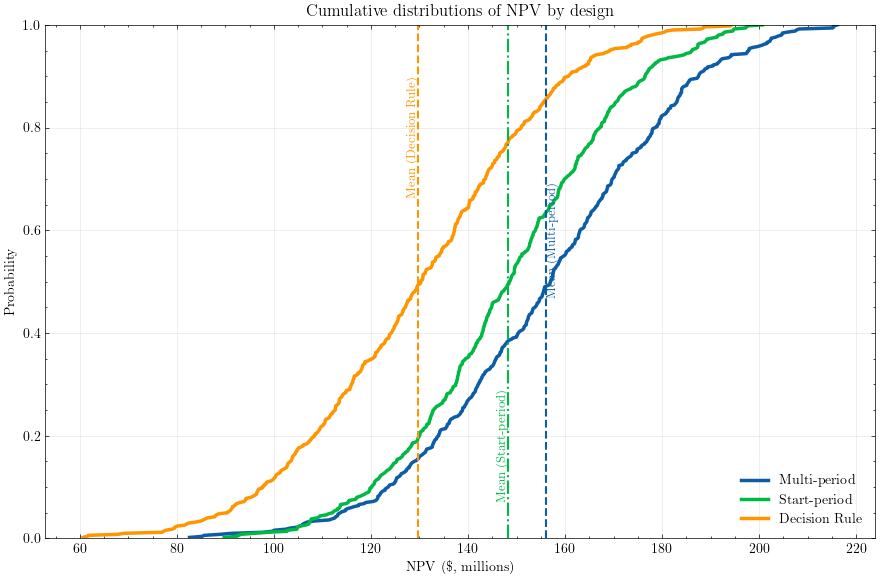

In [76]:
# ============================================
# CDF plot with all four policies
# ============================================
import numpy as np
import matplotlib.pyplot as plt

def make_cdf(x):
    xs = np.sort(np.asarray(x))
    n  = len(xs)
    ys = np.arange(1, n+1) / n
    return xs, ys

SCALE = 1e6  # dollars → $ millions (set to 1 if already in millions)
toM = lambda arr: np.asarray(arr) / SCALE

xM, yM = make_cdf(npv_multi)
xS, yS = make_cdf(npv_single)
xD, yD = make_cdf(npv_decisionrule)

mean_M = np.mean(npv_multi)       / SCALE
mean_S = np.mean(npv_single)      / SCALE
mean_D = np.mean(npv_decisionrule)/ SCALE

fig, ax = plt.subplots(figsize=(9, 6))

line_M, = ax.plot(toM(xM), yM, linewidth=2.5, label="Multi-period")
line_S, = ax.plot(toM(xS), yS, linewidth=2.5, label="Start-period")
# line_T, = ax.plot(toM(xT), yT, linewidth=2.5, label="Two Chain", linestyle="-.",)
line_D, = ax.plot(toM(xD), yD, linewidth=2.5, label="Decision Rule")

# Vertical mean lines
ax.axvline(mean_M, linestyle="--", linewidth=1.5, color=line_M.get_color())
ax.axvline(mean_S, linestyle="-.", linewidth=1.5, color=line_S.get_color())
# ax.axvline(mean_T, linestyle="--", linewidth=1.5, color=line_T.get_color())
ax.axvline(mean_D, linestyle="--", linewidth=1.5, color=line_D.get_color())

# Labels: put Single-period label **to the right** of its line
ax.text(mean_M, 0.58, "Mean (Multi-period)", rotation=90,
        va="center", ha="left", fontsize=9, color=line_M.get_color())
ax.text(mean_S, 0.18, "Mean (Start-period)", rotation=90,
        va="center", ha="right",  fontsize=9, color=line_S.get_color())
# ax.text(mean_T, 0.58, "Mean (Two-chain)",    rotation=90,
#         va="center", ha="right", fontsize=9, color=line_T.get_color())
ax.text(mean_D, 0.78, "Mean (Decision Rule)",rotation=90,
        va="center", ha="right",  fontsize=9, color=line_D.get_color())

ax.set_xlabel("NPV (\$, millions)")
ax.set_ylabel("Probability")
ax.set_ylim(0.0, 1.0)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")
ax.set_title("Cumulative distributions of NPV by design")

plt.tight_layout()
plt.show()


In [77]:
def optimize_perfect_information_for_scenario(sid, timelimit=120, output_flag=0):
    """
    Perfect-foresight optimization for one scenario sid:
    chooses u_it, m_it, a_ijt, x_ijt, y_ij with true calendar years.
    Uses:
      - T_I = investment years (e.g., [2025..2028])
      - T_V = valuation years  (e.g., [2025..2032])
      - theta = len(T_I) - 1  (so t_theta = base_year + theta)
      - c_ist[(i, sid, t)], d_j_s_t[(j, sid, t)]
      - p_ij[(i, j)] (use 0 if missing)
    """
    base_year = min(T_I)
    t_theta   = max(T_I)
    T_V_max   = max(T_V)

    p_ij_safe = lambda i, j: p_ij.get((i, j), 0.0)
    disc      = lambda t: 1.0 / (1.0 + r) ** ((t - base_year) + 1)

    mdl = gp.Model(f"PerfectInfo-s{sid}")
    mdl.Params.OutputFlag = output_flag
    mdl.Params.TimeLimit  = timelimit

    # --------------------------
    # Decision variables
    # --------------------------
    m_it  = mdl.addVars(M, T_I, vtype=GRB.BINARY,     name="m")
    a_ijt = mdl.addVars(M, P, T_I, vtype=GRB.BINARY,  name="a")
    u_it  = mdl.addVars(M, T_I, vtype=GRB.BINARY,     name="u")
    x_ijt = mdl.addVars(M, P, T_V, lb=0.0, name="x")
    y_ij  = mdl.addVars(M, P, lb=0.0, ub=1.0, name="y")

    # --------------------------
    # Objective
    # --------------------------
    # Revenue
    revenue = gp.quicksum(
        disc(t) * p_ij_safe(i, j) * x_ijt[i, j, t]
        for i in M for j in P for t in T_V
    )

    # OPEX as life-blocks (pay f_i each active year, discounted to base_year)
    opex_coeff = {}
    for i in M:
        Li = L_i[i]
        for tau in T_I:
            life_end = min(tau + Li - 1, T_V_max)
            if tau <= life_end:
                coeff = sum(disc(t) * f_i[i] for t in range(tau, life_end + 1))
            else:
                coeff = 0.0
            opex_coeff[(i, tau)] = coeff
    opex = gp.quicksum(opex_coeff[(i, tau)] * u_it[i, tau] for i in M for tau in T_I)

    # Machine CAPEX (discounted to start year tau)
    capex_M = gp.quicksum(
        (g_i[i] / (1.0 + r) ** (tau - base_year)) * u_it[i, tau]
        for i in M for tau in T_I
    )

    # Arc CAPEX with increments (discounted to decision year t)
    capex_A = gp.LinExpr()
    for i in M:
        for j in P:
            for t in T_I:
                prev = 0 if t == base_year else a_ijt[i, j, t - 1]
                capex_A += (h_ij[i, j] / (1.0 + r) ** (t - base_year)) * (a_ijt[i, j, t] - prev)

    mdl.setObjective(revenue - opex - capex_M - capex_A, GRB.MAXIMIZE)

    # --------------------------
    # Constraints
    # --------------------------
    # Startup definition with calendar years
    mdl.addConstrs((m_it[i, base_year] == u_it[i, base_year] for i in M), name="startup0")
    mdl.addConstrs((m_it[i, t] - m_it[i, t - 1] == u_it[i, t]
                    for i in M for t in T_I if t > base_year), name="startup")

    # Arc monotonicity
    mdl.addConstrs((a_ijt[i, j, t] >= a_ijt[i, j, t - 1]
                    for i in M for j in P for t in T_I if t > base_year), name="arc_mono")

    # Arc can only exist if machine is on
    mdl.addConstrs((a_ijt[i, j, t] <= m_it[i, t]
                    for i in M for j in P for t in T_I), name="arc_machine")

    # Existing qualifications are available whenever the existing machine is active.
    mdl.addConstrs(
        (a_ijt[i, j, t] == m_it[i, t]
         for i, j in pre_installed_arcs for t in T_I),
        name="preinstalled_capability"
    )

    # Lifetime restriction beyond t_theta:
    # Σ_j x_ijt ≤ c_ist * (Σ starts in last L_i years, bounded in [base_year..t_theta])
    for i in M:
        Li = L_i[i]
        for t in range(t_theta + 1, T_V_max + 1):
            mdl.addConstr(
                gp.quicksum(x_ijt[i, j, t] for j in P) <=
                c_ist[(i, sid, t)] *
                gp.quicksum(u_it[i, tau]
                            for tau in range(max(base_year, t - Li + 1), min(t, t_theta) + 1)),
                name=f"life_cap_{i}_{t}"
            )

    # Demand
    mdl.addConstrs(
        (gp.quicksum(x_ijt[i, j, t] for i in M) <= d_j_s_t[(j, sid, t)]
         for j in P for t in T_V),
        name="demand"
    )

    # Capacity: freeze machine state after t_theta
    mdl.addConstrs(
        (gp.quicksum(x_ijt[i, j, t] for j in P)/throughput <=
         c_ist[(i, sid, t)] * (m_it[i, t] if t <= t_theta else m_it[i, t_theta])
         for i in M for t in T_V),
        name="capacity"
    )

    # Arc link: freeze arc state after t_theta
    mdl.addConstrs(
        (x_ijt[i, j, t]/throughput <=
         c_ist[(i, sid, t)] * (a_ijt[i, j, t] if t <= t_theta else a_ijt[i, j, t_theta])
         for i in M for j in P for t in T_V),
        name="arc_link"
    )

    # Share definition & freezing
    mdl.addConstrs(
        (x_ijt[i, j, t_theta] <= y_ij[i, j] * d_j_s_t[(j, sid, t_theta)]
         for i in M for j in P),
        name="share_def"
    )
    mdl.addConstrs(
        (x_ijt[i, j, t] <= y_ij[i, j] * d_j_s_t[(j, sid, t)]
         for i in M for j in P for t in T_V if t > t_theta),
        name="share_frozen"
    )

    # Share completeness per product
    mdl.addConstrs(
        (gp.quicksum(y_ij[i, j] for i in M) == 1.0 for j in P),
        name="share_sum"
    )

    mdl.optimize()
    if mdl.Status != GRB.OPTIMAL:
        raise RuntimeError(
            f"Perfect-information scenario {sid} did not solve to optimality; "
            f"status={mdl.Status}"
        )
    return mdl.ObjVal


In [78]:
npv_perfect = []
for sid in S:
    val = optimize_perfect_information_for_scenario(sid, output_flag=0)
    npv_perfect.append(val)

print("Mean Perfect Information:", np.mean(npv_perfect))


Mean Perfect Information: 160953897.368858


<>:61: SyntaxWarning: invalid escape sequence '\$'
<>:61: SyntaxWarning: invalid escape sequence '\$'
/var/folders/sj/st6tx4490j9cw4yh3mw2mcyh0000gp/T/ipykernel_8253/505954927.py:61: SyntaxWarning: invalid escape sequence '\$'
  ax.set_xlabel("Objective (\$M)")


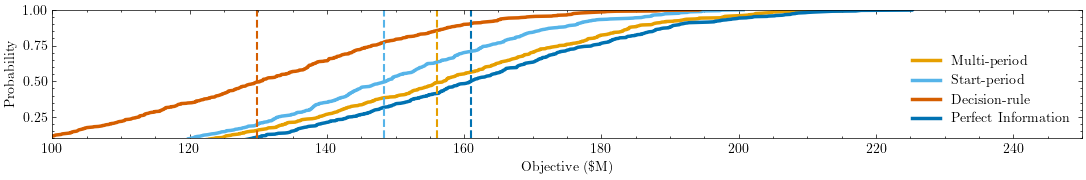

In [83]:
import numpy as np
import matplotlib.pyplot as plt

def make_cdf(x):
    xs = np.sort(np.asarray(x))
    n  = len(xs)
    ys = np.arange(1, n+1) / n
    return xs, ys

SCALE = 1e6  # dollars → $ millions (set to 1 if already in millions)
toM = lambda arr: np.asarray(arr) / SCALE

xM, yM = make_cdf(npv_multi)
xS, yS = make_cdf(npv_single)
# xT, yT = make_cdf(npv_two_chain)
xD, yD = make_cdf(npv_decisionrule)
xP, yP = make_cdf(npv_perfect)

mean_M = np.mean(npv_multi)       / SCALE
mean_S = np.mean(npv_single)      / SCALE
# mean_T = np.mean(npv_two_chain)   / SCALE
mean_D = np.mean(npv_decisionrule)/ SCALE
mean_P = np.mean(npv_perfect)     / SCALE

# Okabe-Ito color-blind friendly palette
colors = {
    "Multi-period":      "#E69F00",  # orange
    "Start-period":      "#56B4E9",  # sky blue
    "Long-chain":         "#009E73",  # bluish green
    "Decision-rule":     "#D55E00",  # red
    "Perfect":           "#0072B2",  # blue
}

fig, ax = plt.subplots(figsize=(11, 2))

line_M, = ax.plot(toM(xM), yM, linewidth=2.5, color=colors["Multi-period"], label="Multi-period")
line_S, = ax.plot(toM(xS), yS, linewidth=2.5, color=colors["Start-period"], label="Start-period")
# line_T, = ax.plot(toM(xT), yT, linewidth=2.5, color=colors["Long-chain"], label="Long-chain")
line_D, = ax.plot(toM(xD), yD, linewidth=2.5, color=colors["Decision-rule"], label="Decision-rule")
line_P, = ax.plot(toM(xP), yP, linewidth=2.5, color=colors["Perfect"], label="Perfect Information")

# Vertical mean lines
ax.axvline(mean_M, linestyle="--", linewidth=1.5, color=colors["Multi-period"])
ax.axvline(mean_S, linestyle="--", linewidth=1.5, color=colors["Start-period"])
# ax.axvline(mean_T, linestyle="--", linewidth=1.5, color=colors["Long-chain"])
ax.axvline(mean_D, linestyle="--", linewidth=1.5, color=colors["Decision-rule"])
ax.axvline(mean_P, linestyle="--", linewidth=1.5, color=colors["Perfect"])

# # Text labels
# ax.text(mean_M, 0.58, "Mean (Multi-period)", rotation=90,
#         va="center", ha="left", fontsize=9, color=colors["Multi-period"])
# ax.text(mean_S, 0.20, "Mean (Start-period)", rotation=90,
#         va="center", ha="left", fontsize=9, color=colors["Start-period"])
# ax.text(mean_T, 0.58, "Mean (Two-chain)",    rotation=90,
#         va="center", ha="right", fontsize=9, color=colors["Two-chain"])
# ax.text(mean_D, 0.78, "Mean (Decision Rule)",rotation=90,
#         va="center", ha="right",  fontsize=9, color=colors["Decision-rule"])
# ax.text(mean_P, 0.18, "Mean (Perfect)", rotation=90,
#         va="center", ha="left", fontsize=9, color=colors["Perfect"])

ax.set_xlabel("Objective (\$M)")
ax.set_ylabel("Probability")
ax.set_ylim(0.1, 1.0)
ax.set_xlim(100, 250)
#ax.grid(True, alpha=0.3)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("cdfcasestudy.pdf")
plt.show()


<>:61: SyntaxWarning: invalid escape sequence '\$'
<>:61: SyntaxWarning: invalid escape sequence '\$'
/var/folders/sj/st6tx4490j9cw4yh3mw2mcyh0000gp/T/ipykernel_8253/3213222718.py:61: SyntaxWarning: invalid escape sequence '\$'
  ax.set_xlabel("Objective (\$M)")


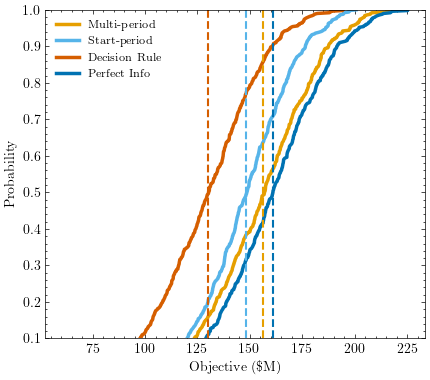

In [80]:
import numpy as np
import matplotlib.pyplot as plt

def make_cdf(x):
    xs = np.sort(np.asarray(x))
    n  = len(xs)
    ys = np.arange(1, n+1) / n
    return xs, ys

SCALE = 1e6  # dollars → $ millions (set to 1 if already in millions)
toM = lambda arr: np.asarray(arr) / SCALE

xM, yM = make_cdf(npv_multi)
xS, yS = make_cdf(npv_single)
#xT, yT = make_cdf(npv_two_chain)
xD, yD = make_cdf(npv_decisionrule)
xP, yP = make_cdf(npv_perfect)

mean_M = np.mean(npv_multi)       / SCALE
mean_S = np.mean(npv_single)      / SCALE
#mean_T = np.mean(npv_two_chain)   / SCALE
mean_D = np.mean(npv_decisionrule)/ SCALE
mean_P = np.mean(npv_perfect)     / SCALE

# Okabe-Ito color-blind friendly palette
colors = {
    "Multi-period":      "#E69F00",  # orange
    "Start-period":      "#56B4E9",  # sky blue
    "Two-chain":         "#009E73",  # bluish green
    "Decision-rule":     "#D55E00",  # red
    "Perfect":           "#0072B2",  # blue
}

fig, ax = plt.subplots(figsize=(4.5, 4))

line_M, = ax.plot(toM(xM), yM, linewidth=2.5, color=colors["Multi-period"], label="Multi-period")
line_S, = ax.plot(toM(xS), yS, linewidth=2.5, color=colors["Start-period"], label="Start-period")
#line_T, = ax.plot(toM(xT), yT, linewidth=2.5, color=colors["Two-chain"], label="Two-chain")
line_D, = ax.plot(toM(xD), yD, linewidth=2.5, color=colors["Decision-rule"], label="Decision Rule")
line_P, = ax.plot(toM(xP), yP, linewidth=2.5, color=colors["Perfect"], label="Perfect Info")

# Vertical mean lines
ax.axvline(mean_M, linestyle="--", linewidth=1.5, color=colors["Multi-period"])
ax.axvline(mean_S, linestyle="--", linewidth=1.5, color=colors["Start-period"])
#ax.axvline(mean_T, linestyle="--", linewidth=1.5, color=colors["Two-chain"])
ax.axvline(mean_D, linestyle="--", linewidth=1.5, color=colors["Decision-rule"])
ax.axvline(mean_P, linestyle="--", linewidth=1.5, color=colors["Perfect"])

# # Text labels
# ax.text(mean_M, 0.58, "Mean (Multi-period)", rotation=90,
#         va="center", ha="left", fontsize=9, color=colors["Multi-period"])
# ax.text(mean_S, 0.20, "Mean (Start-period)", rotation=90,
#         va="center", ha="left", fontsize=9, color=colors["Start-period"])
# ax.text(mean_T, 0.58, "Mean (Two-chain)",    rotation=90,
#         va="center", ha="right", fontsize=9, color=colors["Two-chain"])
# ax.text(mean_D, 0.78, "Mean (Decision Rule)",rotation=90,
#         va="center", ha="right",  fontsize=9, color=colors["Decision-rule"])
# ax.text(mean_P, 0.18, "Mean (Perfect)", rotation=90,
#         va="center", ha="left", fontsize=9, color=colors["Perfect"])

ax.set_xlabel("Objective (\$M)")
ax.set_ylabel("Probability")
ax.set_ylim(0.1, 1.0)
#ax.grid(True, alpha=0.3)
ax.legend(loc="best", fontsize="small")

plt.tight_layout()
plt.savefig("cdf2e1c1l.pdf")
plt.show()


In [81]:
import numpy as np
import pandas as pd

def summarize(arr, scale=1e6):
    """Return summary statistics in $ millions."""
    arr = np.asarray(arr, dtype=float) / scale
    return {
        "mean": np.mean(arr),
        "median": np.median(arr),
        "q1": np.percentile(arr, 25),
        "q3": np.percentile(arr, 75),
        "min": np.min(arr),
        "max": np.max(arr),
        "std": np.std(arr, ddof=1),
    }

summaries = {
    "Multi-period": summarize(npv_multi),
    "Start-period": summarize(npv_single),
    "Decision-rule": summarize(npv_decisionrule),
    "Perfect Information": summarize(npv_perfect),
}

df_stats = pd.DataFrame(summaries).T
print(df_stats.round(3))


                        mean   median       q1       q3     min      max  \
Multi-period         156.064  157.007  138.886  174.039  82.608  216.105   
Start-period         148.318  148.564  132.989  163.614  89.748  200.654   
Decision-rule        129.785  130.291  112.643  146.587  60.677  194.318   
Perfect Information  160.954  161.012  143.583  178.647  96.007  225.318   

                        std  
Multi-period         25.129  
Start-period         21.634  
Decision-rule        24.558  
Perfect Information  24.623  


In [82]:
# =============================================================================
# Export paper-ready case-study results after a complete rerun
# =============================================================================

paper_output_dir = EVALUATION_OUTPUT_DIR
paper_output_dir.mkdir(parents=True, exist_ok=True)

# Mean NPVs in dollars and millions.
mean_multi = float(np.mean(npv_multi))
mean_start = float(np.mean(npv_single))
mean_dr = float(np.mean(npv_decisionrule))
mean_pi = float(np.mean(npv_perfect))

vmp_abs = mean_multi - mean_start
vmp_pct = 100.0 * vmp_abs / mean_start if mean_start != 0 else np.nan

summary_export = pd.DataFrame([
    {"design": "Multi-period", "mean_npv": mean_multi, "mean_npv_millions": mean_multi / 1e6},
    {"design": "Start-period", "mean_npv": mean_start, "mean_npv_millions": mean_start / 1e6},
    {"design": "Decision-rule", "mean_npv": mean_dr, "mean_npv_millions": mean_dr / 1e6},
    {"design": "Perfect Information", "mean_npv": mean_pi, "mean_npv_millions": mean_pi / 1e6},
])
summary_export.to_csv(
    paper_output_dir / "case_study_npv_summary.csv", index=False
)

# Start-period new capabilities.
baseline_edges = set(pre_installed_arcs)
start_selected = {
    (i, j) for (i, j), value in a_ij_two.items() if value > 0.5
}
start_new_edges = sorted(start_selected - baseline_edges)

# Multi-period additions by year.
multi_addition_rows = []
installed = set(baseline_edges)
for t in sorted(T_I):
    current = {
        (i, j)
        for (i, j, tt), value in a_ijt_multi.items()
        if tt == t and value > 0.5
    }
    for i, j in sorted(current - installed):
        multi_addition_rows.append({"year": t, "machine": i, "product": j})
    installed |= current

pd.DataFrame(
    [{"machine": i, "product": j} for i, j in start_new_edges]
).to_csv(paper_output_dir / "start_period_new_capabilities.csv", index=False)

pd.DataFrame(multi_addition_rows).to_csv(
    paper_output_dir / "multi_period_capability_additions.csv", index=False
)

# A compact text file that can be used to update the manuscript without
# copying stale notebook output.
lines = [
    f"Evaluation scenarios: {len(S)}",
    f"Multi-period mean NPV: ${mean_multi/1e6:.3f}M",
    f"Start-period mean NPV: ${mean_start/1e6:.3f}M",
    f"Decision-rule mean NPV: ${mean_dr/1e6:.3f}M",
    f"Perfect-information mean NPV: ${mean_pi/1e6:.3f}M",
    f"VMP (MP - SP): ${vmp_abs/1e6:.3f}M ({vmp_pct:.2f}%)",
    f"Start-period new capabilities: {len(start_new_edges)}",
    f"Multi-period new capabilities: {len(multi_addition_rows)}",
]
for row in multi_addition_rows:
    lines.append(
        f"{row['year']}: ({row['machine']}, {row['product']})"
    )

with open(
    paper_output_dir / "paper_case_study_values.txt",
    "w",
    encoding="utf-8",
) as f:
    f.write("\n".join(lines) + "\n")

print("\n".join(lines))
print(
    "\nPaper-ready files written to:",
    paper_output_dir.resolve(),
)

# Scenario-level results used to reproduce the CDF and summary statistics.
scenario_evaluation = pd.DataFrame({
    "scenario": list(S),
    "multi_period_npv": npv_multi,
    "start_period_npv": npv_single,
    "decision_rule_npv": npv_decisionrule,
    "perfect_information_npv": npv_perfect,
})
scenario_evaluation.to_csv(
    paper_output_dir / "case_study_evaluation.csv", index=False
)

# Preserve the original plot cells and filenames, while also copying the
# manuscript-referenced PDFs into ./Figures for direct Overleaf synchronization.
from shutil import copy2
FIGURE_DIR = Path("Figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
_paper_figure_files = [
    "demand_profit_4rows.pdf",
    "networkplots.pdf",
    "machine_capacity.pdf",
    "cdfcasestudy.pdf",
    "demand_2x9_sorted_grid_with_labels.pdf",
]
for _filename in _paper_figure_files:
    _src = Path(_filename)
    if _src.exists():
        copy2(_src, FIGURE_DIR / _filename)
        print(f"Copied {_filename} -> {FIGURE_DIR / _filename}")
    else:
        print(f"Figure not found yet (run its plot cell first): {_filename}")



Evaluation scenarios: 500
Multi-period mean NPV: $156.064M
Start-period mean NPV: $148.318M
Decision-rule mean NPV: $129.785M
Perfect-information mean NPV: $160.954M
VMP (MP - SP): $7.746M (5.22%)
Start-period new capabilities: 7
Multi-period new capabilities: 8
2025: (Machine 1, Growth 7)
2025: (Machine 1, Mature 3)
2025: (Machine 1, Mature 4)
2025: (Machine 2, Decline 5)
2026: (Machine 2, Growth 6)
2028: (Machine 1, Growth 9)
2030: (Machine 3, Growth 6)
2030: (Machine 3, Growth 9)

Paper-ready files written to: /Users/saragih/Downloads/ROSRV/6.CaseStudy/saa_outputs/evaluation
Copied demand_profit_4rows.pdf -> Figures/demand_profit_4rows.pdf
Copied networkplots.pdf -> Figures/networkplots.pdf
Copied machine_capacity.pdf -> Figures/machine_capacity.pdf
Copied cdfcasestudy.pdf -> Figures/cdfcasestudy.pdf
Copied demand_2x9_sorted_grid_with_labels.pdf -> Figures/demand_2x9_sorted_grid_with_labels.pdf
